In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

import re,time
import string
import nltk

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,f1_score,classification_report,confusion_matrix,ConfusionMatrixDisplay
import warnings
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from tqdm.notebook import tqdm
# -----------------------------
# Load Dataset
# -----------------------------
from pathlib import Path
PROJECT_DIR = (Path.cwd() /'..').resolve()
OUTPUTS_DIR = PROJECT_DIR/ 'outputs'
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)
TRAIN_PATH = PROJECT_DIR/ 'data'/ 'train.csv'
TEST_PATH  = PROJECT_DIR/ 'data'/ 'test.csv'
df = pd.read_csv(TRAIN_PATH)

# TASK1:Data Exploration and Visualization

Dataset Shape: (288000, 2)

Columns: Index(['text', 'rating'], dtype='object')

First 5 rows:
                                                 text  rating
0  This place is TERRIBLE; the people in charge a...       2
1  Terrible Service! And they are saying that I n...       1
2  Absolutely terrible company.  They sent me to ...       1
3  To find it, either park in front of the Tuesda...       4
4  Mall location. Used their services for sedan. ...       4

Missing Values:
 text      0
rating    0
dtype: int64
Train shape:(288000, 2) , columns: ['text', 'rating']

Label distribution (%):
rating
1    38.05%
2    11.19%
3    12.27%
4     28.5%
5     10.0%
Name: proportion, dtype: object

First 5 rows:
                                                 text  rating
0  This place is TERRIBLE; the people in charge a...       2
1  Terrible Service! And they are saying that I n...       1
2  Absolutely terrible company.  They sent me to ...       1
3  To find it, either park in front of the Tue

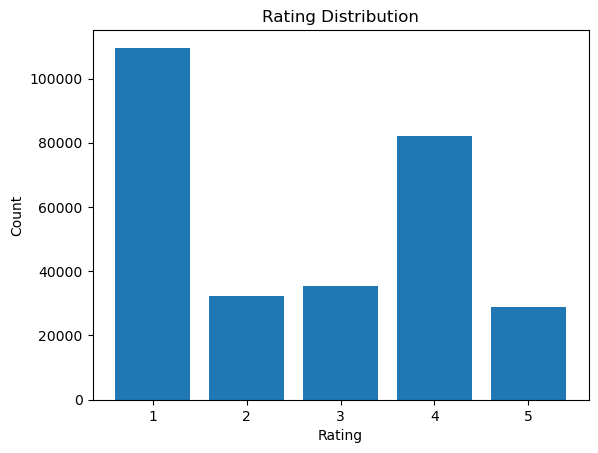


Word Count Summary:
 count    288000.000000
mean         58.695444
std          80.353889
min           1.000000
25%          12.000000
50%          32.000000
75%          72.000000
max        1533.000000
Name: word_count, dtype: float64


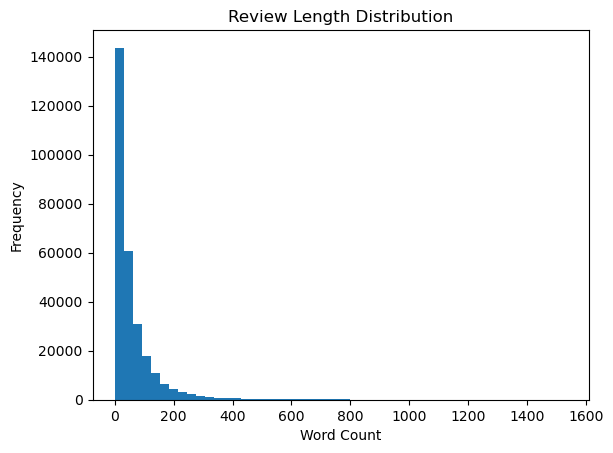


Average Review Length by Rating:
 rating
1    81.615387
2    76.244615
3    46.774868
4    32.712000
5    40.522188
Name: word_count, dtype: float64


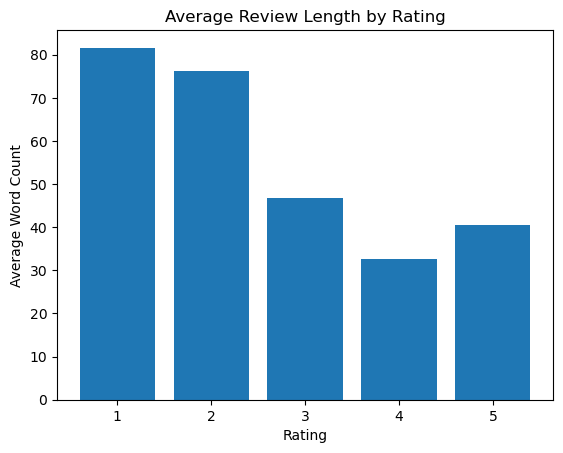


Top 20 Most Common Words:
 [('the', 689895), ('and', 537695), ('to', 513101), ('i', 488694), ('a', 374636), ('was', 239772), ('they', 215527), ('my', 215343), ('for', 201520), ('of', 198805), ('in', 178564), ('is', 176385), ('that', 151184), ('it', 142870), ('not', 141581), ('this', 130130), ('with', 127829), ('have', 122552), ('you', 116858), ('on', 112338)]


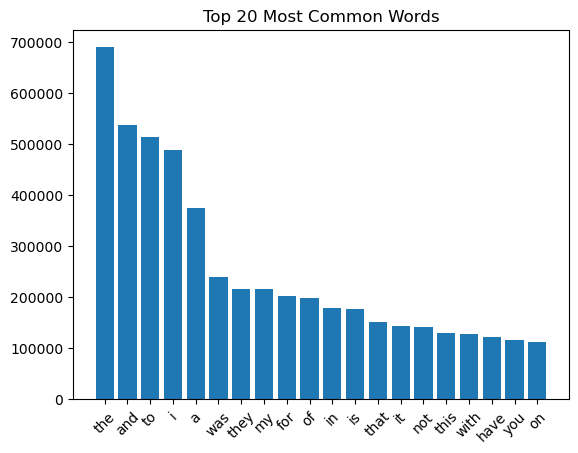

In [2]:
# -----------------------------
# Basic Inspection
# -----------------------------
print("Dataset Shape:", df.shape)
print("\nColumns:", df.columns)
print("\nFirst 5 rows:\n", df.head())

df = df.dropna(subset=['text', 'rating'])
df['text'] = df['text'].astype(str)
df['rating'] = df['rating'].astype(int)

print("\nMissing Values:\n", df.isnull().sum())
print(f"Train shape:{df.shape} , columns: {df.columns.tolist()}")
print("\nLabel distribution (%):")
print((df['rating'].value_counts(normalize=True).sort_index() * 100).round(2).astype(str) + "%")

print("\nFirst 5 rows:\n", df.head())

# -----------------------------
# 4. Rating Distribution
# -----------------------------
rating_counts = df['rating'].value_counts().sort_index()
# print("\nRating Distribution:\n", rating_counts)
plt.bar(rating_counts.index, rating_counts.values)
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

# -----------------------------
# 5. Review Length Analysis
# -----------------------------
df['word_count'] = df['text'].apply(lambda x: len(x.split()))

print("\nWord Count Summary:\n", df['word_count'].describe())

plt.hist(df['word_count'], bins=50)
plt.title("Review Length Distribution")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.show()

# -----------------------------
# 6. Average Length by Rating
# -----------------------------
avg_length = df.groupby('rating')['word_count'].mean()

print("\nAverage Review Length by Rating:\n", avg_length)

plt.bar(avg_length.index, avg_length.values)
plt.title("Average Review Length by Rating")
plt.xlabel("Rating")
plt.ylabel("Average Word Count")
plt.show()

# -----------------------------
# 7. Most Common Words
# -----------------------------
all_words = " ".join(df['text']).lower().split()
common_words = Counter(all_words).most_common(20)

print("\nTop 20 Most Common Words:\n", common_words)

words = [w for w, c in common_words]
counts = [c for w, c in common_words]

plt.bar(words, counts)
plt.title("Top 20 Most Common Words")
plt.xticks(rotation=45)
plt.show()

# Task2:Text Processing and Normalization: (15%) 

In [3]:
# -----------------------------
# NLP tools
# -----------------------------
nltk.download('stopwords')
nltk.download('wordnet')
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

# -----------------------------
# Preprocessing functions
# -----------------------------
def basic_clean(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    return text

def remove_stopwords_tokens(tokens):
    return [w for w in tokens if w not in stop_words]

def stem_tokens(tokens):
    return [stemmer.stem(w) for w in tokens]

def lemma_tokens(tokens):
    return [lemmatizer.lemmatize(w, pos='v') for w in tokens]

def tokenize(text):
    return text.split()

#use small data size
df_sample, _ = train_test_split(
    df,
    train_size=3000,
    stratify=df["rating"],
    random_state=42
)

df_sample['original'] = df_sample['text']
df_sample['clean'] = df_sample['text'].apply(basic_clean)
df_sample['tokens'] = df_sample['clean'].apply(tokenize)
df_sample['tokens_nostop'] = df_sample['tokens'].apply(remove_stopwords_tokens)
df_sample['tokens_stem'] = df_sample['tokens_nostop'].apply(stem_tokens)
df_sample['tokens_lemma'] = df_sample['tokens_nostop'].apply(lemma_tokens)

df_sample['nostop'] = df_sample['tokens_nostop'].apply(lambda x: " ".join(x))
df_sample['stem']   = df_sample['tokens_stem'].apply(lambda x: " ".join(x))
df_sample['lemma']  = df_sample['tokens_lemma'].apply(lambda x: " ".join(x))

X = df_sample['text']
y = df_sample['rating']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

train_idx = X_train.index
test_idx = X_test.index

# -----------------------------
# Evaluation function
# -----------------------------
def evaluate(column_name):
    X_train_col = df_sample.loc[train_idx, column_name]
    X_test_col = df_sample.loc[test_idx, column_name]

    y_train_col = df_sample.loc[train_idx, 'rating']
    y_test_col = df_sample.loc[test_idx, 'rating']

    model = Pipeline([
        ('tfidf', TfidfVectorizer()),
        ('clf', LogisticRegression(max_iter=1000))
    ])

    model.fit(X_train_col, y_train_col)
    preds = model.predict(X_test_col)

    acc = accuracy_score(y_test_col, preds)
    f1 = f1_score(y_test_col, preds, average="macro")

    print(f"{column_name} Accuracy: {acc:.4f}, Macro-F1: {f1:.4f}")

    return {
        "method": column_name,
        "accuracy": acc,
        "macro_f1": f1
    }

# -----------------------------
# Compare all methods
# -----------------------------
print("\nModel Performance:")
results = []
results.append(evaluate('original'))
results.append(evaluate('clean'))
results.append(evaluate('nostop'))
results.append(evaluate('stem'))
results.append(evaluate('lemma'))

text_process_results_df = pd.DataFrame(results)

text_process_results_df = text_process_results_df.sort_values(by="macro_f1", ascending=False)

print("\nSorted Results:")
print(text_process_results_df)

best_method = text_process_results_df.iloc[0]["method"]
print(f"\nBest preprocessing method: {best_method}")

output_path = OUTPUTS_DIR / "processed_data.csv"
df_sample.to_csv(output_path, index=False)
print(f"\nSaved processed dataframe to: {output_path}")

results_path = OUTPUTS_DIR / "preprocessing_results.csv"
text_process_results_df.to_csv(results_path, index=False)

print(f"Saved results to: {results_path}")

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/gobika/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /Users/gobika/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!



Model Performance:
original Accuracy: 0.6200, Macro-F1: 0.3976
clean Accuracy: 0.6317, Macro-F1: 0.4107
nostop Accuracy: 0.6083, Macro-F1: 0.3682
stem Accuracy: 0.6117, Macro-F1: 0.3777
lemma Accuracy: 0.6183, Macro-F1: 0.3828

Sorted Results:
     method  accuracy  macro_f1
1     clean  0.631667  0.410717
0  original  0.620000  0.397572
4     lemma  0.618333  0.382773
3      stem  0.611667  0.377715
2    nostop  0.608333  0.368157

Best preprocessing method: clean

Saved processed dataframe to: /Users/gobika/Documents/HW_Projects/F21AA-CW2/Applied_Text_Analytics_CW2/outputs/processed_data.csv
Saved results to: /Users/gobika/Documents/HW_Projects/F21AA-CW2/Applied_Text_Analytics_CW2/outputs/preprocessing_results.csv


# TASK3:Vector space Model and feature representation

In [4]:
nltk.download('omw-1.4')

#use the same data as TASK2
X_train = df_sample.loc[train_idx, best_method]
X_val = df_sample.loc[test_idx, best_method]

y_train = df_sample.loc[train_idx, 'rating']
y_val = df_sample.loc[test_idx, 'rating']

# ---------------------------------
# 4. Function to train and evaluate model
# ---------------------------------
results = []

def evaluate_model(model_name, vectorizer):
    model = Pipeline([
        ('vectorizer', vectorizer),
        ('classifier', LogisticRegression(max_iter=1000))
    ])

    model.fit(X_train, y_train)
    predictions = model.predict(X_val)

    accuracy = accuracy_score(y_val, predictions)
    Macro_F1  = f1_score(y_val, predictions, average='macro')

    print(f"\n{'='*60}\nModel: {model_name} | Feature size: {len(model.named_steps['vectorizer'].vocabulary_)} | Acc: {accuracy:.4f} | Macro-F1: {Macro_F1:.4f}")

    results.append({
        'Model': model_name,
        'Accuracy': round(accuracy, 4),
        'Macro_F1 ': round(Macro_F1 , 4),
        'model_obj': model
    })

# ---------------------------------
# 5. Experiment 1: Bag of Words
# ---------------------------------
evaluate_model(
    "Bag of Words - Unigram",
    CountVectorizer(ngram_range=(1,1))
)

evaluate_model(
    "Bag of Words - Unigram + Bigram",
    CountVectorizer(ngram_range=(1,2))
)

evaluate_model(
    "Bag of Words - Unigram + Bigram + Trigram",
    CountVectorizer(ngram_range=(1,3), min_df=2)
)

# ---------------------------------
# 6. Experiment 2: TF-IDF
# ---------------------------------
evaluate_model(
    "TF-IDF - Unigram",
    TfidfVectorizer(ngram_range=(1,1))
)

evaluate_model(
    "TF-IDF - Unigram + Bigram",
    TfidfVectorizer(ngram_range=(1,2))
)

evaluate_model(
    "TF-IDF - Unigram + Bigram + Trigram",
    TfidfVectorizer(ngram_range=(1,3), min_df=2)
)

[nltk_data] Downloading package omw-1.4 to /Users/gobika/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!



Model: Bag of Words - Unigram | Feature size: 9981 | Acc: 0.5983 | Macro-F1: 0.4603

Model: Bag of Words - Unigram + Bigram | Feature size: 76950 | Acc: 0.6283 | Macro-F1: 0.4673

Model: Bag of Words - Unigram + Bigram + Trigram | Feature size: 24616 | Acc: 0.6133 | Macro-F1: 0.4526

Model: TF-IDF - Unigram | Feature size: 9981 | Acc: 0.6317 | Macro-F1: 0.4107

Model: TF-IDF - Unigram + Bigram | Feature size: 76950 | Acc: 0.5950 | Macro-F1: 0.3378

Model: TF-IDF - Unigram + Bigram + Trigram | Feature size: 24616 | Acc: 0.6050 | Macro-F1: 0.3557


In [5]:
# ---------------------------------
# 7. Show final comparison table
# ---------------------------------
results_df = pd.DataFrame(results)

print("\n" + "="*60)
print("Final Comparison of Feature Representation Methods")
print(results_df.sort_values(by='Macro_F1 ', ascending=False))

best_model = results_df.iloc[0]["model_obj"]
best_model_name = results_df.iloc[0]["Model"]
print("Best model:", best_model_name)

print("\nClassification Report:\n")
preds = best_model.predict(X_val)
print(classification_report(y_val, preds))


Final Comparison of Feature Representation Methods
                                       Model  Accuracy  Macro_F1   \
1            Bag of Words - Unigram + Bigram    0.6283     0.4673   
0                     Bag of Words - Unigram    0.5967     0.4595   
2  Bag of Words - Unigram + Bigram + Trigram    0.6133     0.4526   
3                           TF-IDF - Unigram    0.6317     0.4107   
5        TF-IDF - Unigram + Bigram + Trigram    0.6050     0.3557   
4                  TF-IDF - Unigram + Bigram    0.5950     0.3378   

                                           model_obj  
1  (CountVectorizer(ngram_range=(1, 2)), Logistic...  
0  (CountVectorizer(), LogisticRegression(max_ite...  
2  (CountVectorizer(min_df=2, ngram_range=(1, 3))...  
3  (TfidfVectorizer(), LogisticRegression(max_ite...  
5  (TfidfVectorizer(min_df=2, ngram_range=(1, 3))...  
4  (TfidfVectorizer(ngram_range=(1, 2)), Logistic...  
Best model: Bag of Words - Unigram

Classification Report:

              preci

# TASK 4: Model Training, Selection and Evaluation

## Text Processing and Normalization
Based on the results of Task 2, the original text achieved the best performance. However, the original version showed comparable results with only a marginal decrease in Macro-F1. 

Therefore, instead of selecting only the best-performing option, both the original and cleaned text representations were retained for further experimentation in Task 4. This allows us to evaluate whether slight normalization can improve model performance when combined with different classifiers.

## Vector Space Model and Feature Representation
Based on the results of Task 3, Bag-of-Words with unigram and bigram features achieved the highest Macro-F1 score, while the inclusion of trigrams provided similar but slightly lower performance.

In Task 4, both unigram+bigram and unigram+bigram+trigram configurations are explored. This enables us to examine whether more complex n-gram features may benefit certain models despite the increased sparsity.

Additionally, TF-IDF is included as a comparison representation to evaluate whether term weighting can improve classification performance over raw frequency-based features.

## Data Setup
The top two preprocessing methods identified in Task 2 are used to construct the training and test sets for model evaluation.

In [47]:
warnings.filterwarnings("ignore", category=UserWarning)

# Reuse Task2 data
top2_methods = text_process_results_df["method"].head(2).tolist()
print("Top 2 preprocessing methods:", top2_methods)

text_versions = {}

for method in top2_methods:
    text_versions[method] = {
        "X_train": df_sample.loc[train_idx, method],
        "X_test": df_sample.loc[test_idx, method]
    }

y_train = df_sample.loc[train_idx, "rating"]
y_test = df_sample.loc[test_idx, "rating"]

print("Data split summary:")
for text_name, data in text_versions.items():
    print(f"{text_name} -> train: {data['X_train'].shape}, test: {data['X_test'].shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test : {y_test.shape}")

Top 2 preprocessing methods: ['clean', 'original']
Data split summary:
clean -> train: (2400,), test: (600,)
original -> train: (2400,), test: (600,)
y_train: (2400,)
y_test : (600,)


## Feature Configuration

Bag-of-Words and TF-IDF feature representations are defined here for model training and comparison.

In [48]:
# Reuse feature representations from Task3
bow_12_feature = {
    "name": "BoW_(1,2)",
    "vectorizer": CountVectorizer(ngram_range=(1, 2))
}

bow_13_feature = {
    "name": "BoW_(1,3)_min_df2",
    "vectorizer": CountVectorizer(ngram_range=(1, 3), min_df=2)
}

tfidf_11_feature = {
    "name": "TFIDF_(1,1)",
    "vectorizer": TfidfVectorizer(ngram_range=(1, 1))
}

feature_configs = [
    bow_12_feature,
    bow_13_feature,
    tfidf_11_feature
]

## Model Configuration

Different classification models and their corresponding hyperparameter grids are defined here, including Naive Bayes, Logistic Regression, and Linear SVM.

In [49]:
# Model configs
nb_model_config = {
    "name": "MultinomialNB",
    "classifier": MultinomialNB(),
    "param_grid": {
        "classifier__alpha": [0.1, 0.5, 1.0]
    }
}

lr_model_config = {
    "name": "LogisticRegression",
    "classifier": LogisticRegression(max_iter=3000, random_state=42),
    "param_grid": {
        "classifier__C": [0.1, 1.0, 10.0],
        "classifier__class_weight": [None, "balanced"]
    }
}

svm_model_config = {
    "name": "LinearSVC",
    "classifier": LinearSVC(max_iter=5000),
    "param_grid": {
        "classifier__C": [0.1, 1.0, 10.0],
        "classifier__class_weight": [None, "balanced"]
    }
}

model_configs = [
    nb_model_config,
    lr_model_config,
    svm_model_config
]

## Model Training and Evaluation

Functions are defined to perform model training with grid search, evaluate model performance, and record experimental results. These functions are later used to run and compare different model configurations.

In [50]:
def run_grid_search(X_train, y_train, vectorizer, classifier, param_grid):
    pipeline = Pipeline([
        ("vectorizer", vectorizer),
        ("classifier", classifier)
    ])

    grid = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        scoring="f1_macro",
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        n_jobs=-1,
        verbose=0,
        refit=True
    )
    grid.fit(X_train, y_train)
    return grid

def evaluate_best_model(best_model, X_test, y_test):
    y_pred = best_model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average="macro")
    weighted_f1 = f1_score(y_test, y_pred, average="weighted")
    vocab_size = len(best_model.named_steps["vectorizer"].vocabulary_)

    return {
        "Feature_Size": vocab_size,
        "Test_Accuracy": acc,
        "Test_Macro_F1": macro_f1,
        "Test_Weighted_F1": weighted_f1
    }

def save_cv_results(grid, exp_id, exp_name):
    cv_df = pd.DataFrame(grid.cv_results_)[
        ["mean_test_score", "std_test_score", "rank_test_score", "params"]
    ].sort_values(by="rank_test_score")

    cv_df.insert(0, "Experiment_ID", exp_id)
    cv_df.insert(1, "Experiment", exp_name)

    output_path = OUTPUTS_DIR / f"task4_{exp_id:02d}_cv_results.csv"
    cv_df.to_csv(output_path, index=False)
    return output_path

def run_all_experiments_with_grid_search(experiments):
    all_grids = {}
    all_results = []

    pbar = tqdm(experiments, total=len(experiments), desc="Task4 Experiments")

    for exp in pbar:
        exp_id = exp["exp_id"]
        text_name = exp["text_name"]
        text_data = exp["text_data"]
        feature_config = exp["feature_config"]
        model_config = exp["model_config"]

        X_train_current = text_data["X_train"]
        X_test_current = text_data["X_test"]

        feature_name = feature_config["name"]
        vectorizer = feature_config["vectorizer"]

        model_name = model_config["name"]
        classifier = model_config["classifier"]
        param_grid = model_config["param_grid"]

        exp_name = f"{text_name} + {feature_name} + {model_name}"

        pbar.set_postfix({
            "text": text_name,
            "feature": feature_name,
            "model": model_name
        })

        start_time = time.time()

        grid = run_grid_search(
            X_train=X_train_current,
            y_train=y_train,
            vectorizer=vectorizer,
            classifier=classifier,
            param_grid=param_grid
        )

        elapsed = time.time() - start_time

        all_grids[exp_name] = {
            "grid": grid,
            "X_test": X_test_current,
            "y_test": y_test
        }

        cv_path = save_cv_results(grid, exp_id, exp_name)

        test_metrics = evaluate_best_model(
            best_model=grid.best_estimator_,
            X_test=X_test_current,
            y_test=y_test
        )

        all_results.append({
            "Experiment_ID": exp_id,
            "Experiment": exp_name,
            "Text": text_name,
            "Feature": feature_name,
            "Model": model_name,
            "Best_Params": str(grid.best_params_),
            "CV_Macro_F1": grid.best_score_,
            "CV_Results_File": str(cv_path),
            "Run_Time_Seconds": elapsed,
            **test_metrics
        })
    return all_grids, all_results

def plot_confusion_matrix_for_model(model, X_test, y_test, title):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred, labels=sorted(y_test.unique()))
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=sorted(y_test.unique())
    )
    disp.plot()
    plt.title(title)
    plt.show()

    print("\nClassification report:")
    print(classification_report(y_test, y_pred, digits=4))

## Experiment Execution and Result Comparison

Experiments are set up and executed using grid search. The results are compared based on Macro-F1 on the test set to identify the best-performing model. A confusion matrix is generated for further analysis of the selected model.


Total experiments: 18


Task4 Experiments:   0%|          | 0/18 [00:00<?, ?it/s]


Final comparison on test set:


,Experiment_ID,Experiment,Text,Feature,Model,Best_Params,CV_Macro_F1,CV_Results_File,Run_Time_Seconds,Feature_Size,Test_Accuracy,Test_Macro_F1,Test_Weighted_F1
0,2,"clean + BoW_(1,2) + LogisticRegression",clean,"BoW_(1,2)",LogisticRegression,"{'classifier__C': 0.1, 'classifier__class_weig...",0.447338,/home/chao/work/Applied_Text_Analytics_CW2/out...,26.494221,76950,0.606667,0.489737,0.589506
1,5,"clean + BoW_(1,3)_min_df2 + LogisticRegression",clean,"BoW_(1,3)_min_df2",LogisticRegression,"{'classifier__C': 0.1, 'classifier__class_weig...",0.448604,/home/chao/work/Applied_Text_Analytics_CW2/out...,12.713191,24616,0.591667,0.488652,0.583252
2,14,"original + BoW_(1,3)_min_df2 + LogisticRegression",original,"BoW_(1,3)_min_df2",LogisticRegression,"{'classifier__C': 0.1, 'classifier__class_weig...",0.447496,/home/chao/work/Applied_Text_Analytics_CW2/out...,12.346550,24958,0.591667,0.482238,0.582956
3,11,"original + BoW_(1,2) + LogisticRegression",original,"BoW_(1,2)",LogisticRegression,"{'classifier__C': 0.1, 'classifier__class_weig...",0.444688,/home/chao/work/Applied_Text_Analytics_CW2/out...,28.837159,77426,0.601667,0.473688,0.581640
4,12,"original + BoW_(1,2) + LinearSVC",original,"BoW_(1,2)",LinearSVC,"{'classifier__C': 0.1, 'classifier__class_weig...",0.419052,/home/chao/work/Applied_Text_Analytics_CW2/out...,0.651087,77426,0.598333,0.452335,0.569828
5,8,"clean + TFIDF_(1,1) + LogisticRegression",clean,"TFIDF_(1,1)",LogisticRegression,"{'classifier__C': 1.0, 'classifier__class_weig...",0.442056,/home/chao/work/Applied_Text_Analytics_CW2/out...,4.268153,9981,0.546667,0.452108,0.547360
6,17,"original + TFIDF_(1,1) + LogisticRegression",original,"TFIDF_(1,1)",LogisticRegression,"{'classifier__C': 1.0, 'classifier__class_weig...",0.435466,/home/chao/work/Applied_Text_Analytics_CW2/out...,5.216206,9899,0.540000,0.446614,0.544069
7,3,"clean + BoW_(1,2) + LinearSVC",clean,"BoW_(1,2)",LinearSVC,"{'classifier__C': 0.1, 'classifier__class_weig...",0.419184,/home/chao/work/Applied_Text_Analytics_CW2/out...,0.628112,76950,0.605000,0.443242,0.565075
8,15,"original + BoW_(1,3)_min_df2 + LinearSVC",original,"BoW_(1,3)_min_df2",LinearSVC,"{'classifier__C': 0.1, 'classifier__class_weig...",0.419966,/home/chao/work/Applied_Text_Analytics_CW2/out...,1.106547,24958,0.601667,0.443054,0.566175
9,4,"clean + BoW_(1,3)_min_df2 + MultinomialNB",clean,"BoW_(1,3)_min_df2",MultinomialNB,{'classifier__alpha': 0.1},0.441890,/home/chao/work/Applied_Text_Analytics_CW2/out...,0.459307,24616,0.578333,0.442599,0.549720



Saved final comparison to: /home/chao/work/Applied_Text_Analytics_CW2/outputs/task4_all_combinations_comparison.csv

Best experiment on test set: clean + BoW_(1,2) + LogisticRegression
Best parameters: {'classifier__C': 0.1, 'classifier__class_weight': 'balanced'}
Best CV Macro-F1: 0.4473
Best Test Macro-F1: 0.4897


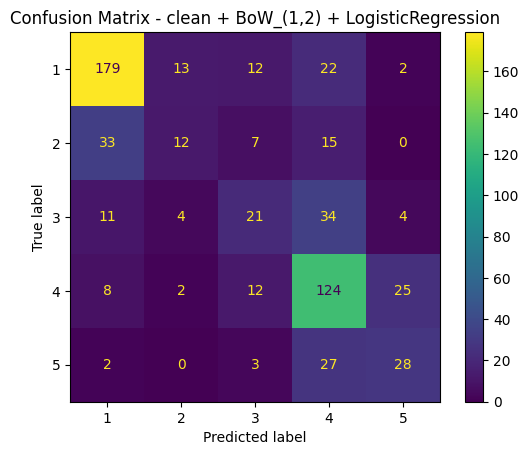


Classification report:
              precision    recall  f1-score   support

           1     0.7682    0.7851    0.7766       228
           2     0.3871    0.1791    0.2449        67
           3     0.3818    0.2838    0.3256        74
           4     0.5586    0.7251    0.6310       171
           5     0.4746    0.4667    0.4706        60

    accuracy                         0.6067       600
   macro avg     0.5141    0.4880    0.4897       600
weighted avg     0.5889    0.6067    0.5895       600



In [51]:
# Build experiment list
experiments = []

exp_id = 1
for text_name, text_data in text_versions.items():
    for feature_config in feature_configs:
        for model_config in model_configs:
            experiments.append({
                "exp_id": exp_id,
                "text_name": text_name,
                "text_data": text_data,
                "feature_config": feature_config,
                "model_config": model_config
            })
            exp_id += 1

print(f"\nTotal experiments: {len(experiments)}")

# Final comparison
all_grids, all_results = run_all_experiments_with_grid_search(experiments)
results_df = pd.DataFrame(all_results).sort_values(
    by="Test_Macro_F1",
    ascending=False
).reset_index(drop=True)

print("\nFinal comparison on test set:")
display(results_df)

results_path = OUTPUTS_DIR / "task4_all_combinations_comparison.csv"
results_df.to_csv(results_path, index=False)
print(f"\nSaved final comparison to: {results_path}")

# Best experiment details
best_row = results_df.iloc[0]
best_exp_name = best_row["Experiment"]
best_grid_info = all_grids[best_exp_name]
best_grid = best_grid_info["grid"]

print(f"\nBest experiment on test set: {best_exp_name}")
print(f"Best parameters: {best_grid.best_params_}")
print(f"Best CV Macro-F1: {best_grid.best_score_:.4f}")
print(f"Best Test Macro-F1: {best_row['Test_Macro_F1']:.4f}")

# Confusion matrix for the best experiment only
plot_confusion_matrix_for_model(
    model=best_grid.best_estimator_,
    X_test=best_grid_info["X_test"],
    y_test=best_grid_info["y_test"],
    title=f"Confusion Matrix - {best_exp_name}"
)

# Analyze
The best performance was achieved using the original text with a Bag-of-Words representation (1–3 grams) and Logistic Regression, reaching a macro-F1 of 0.5246. Overall, Bag-of-Words outperformed TF-IDF, and Logistic Regression consistently performed better than SVM and Naive Bayes. However, performance on minority classes remained weaker, indicating the impact of class imbalance.

# Task 5 - Modelling text as a Sequence

In the previous tasks, text was represented using bag-of-words methods, which treat documents as unordered collections of words. Although such representations are effective, they do not preserve the order in which words appear and therefore cannot fully capture contextual meaning. To address this limitation, this section evaluates several sequence-based models that explicitly process text in order. The experiments include Simple RNN, LSTM, BiLSTM, and DistilBERT, and the results are compared against the best-performing classical baseline from the earlier tasks.

For consistency and fairness, the same train/test split and the best-performing preprocessing method from earlier experiments were reused in the sequence modelling stage. This ensured that any performance differences were mainly due to the modelling approach rather than changes in data preparation.

In [9]:
# If needed, uncomment and run
# !pip install -q torch transformers datasets scikit-learn matplotlib pandas numpy

### Imports and experiment setup

In [10]:
import os
import time
import copy
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.optim import AdamW

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


### Reuse the same data split from your previous tasks
this block reuses the same train/test split and the same text preprocessing method identified as best in the previous tasks. By keeping the data split and input text consistent, any performance differences can be attributed more reliably to the modelling approach rather than changes in the dataset.

In [11]:
if "text_process_results_df" in globals():
    best_method = text_process_results_df.iloc[0]["method"]
else:
    best_method = "text"

print("Best text preprocessing method:", best_method)

X_train_text = df_sample.loc[train_idx, best_method].astype(str).tolist()
X_test_text  = df_sample.loc[test_idx, best_method].astype(str).tolist()

y_train = df_sample.loc[train_idx, "rating"].astype(int).tolist()
y_test  = df_sample.loc[test_idx, "rating"].astype(int).tolist()

print("Train size:", len(X_train_text))
print("Test size :", len(X_test_text))
print("Unique labels:", sorted(set(y_train)))

Best text preprocessing method: clean
Train size: 2400
Test size : 600
Unique labels: [1, 2, 3, 4, 5]


### Baseline score from your previous tasks

the baseline represents the strongest bag-of-words / traditional machine learning model, allowing us to evaluate whether sequence-based models provide an improvement over sparse text representations.

In [12]:
baseline_name = "BoW + Logistic Regression"
baseline_acc = np.nan
baseline_macro_f1 = 0.5246
baseline_weighted_f1 = np.nan

if "results_df" in globals():
    temp_df = results_df.copy()
    temp_df.columns = temp_df.columns.str.strip()

    macro_col = "Test_Macro_F1"
    acc_col = "Test_Accuracy"
    weighted_f1_col = "Test_Weighted_F1"

    temp_df = temp_df.sort_values(by=macro_col, ascending=False).reset_index(drop=True)

    baseline_name = temp_df.loc[0, "Model"]
    baseline_macro_f1 = float(temp_df.loc[0, macro_col])
    baseline_acc = float(temp_df.loc[0, acc_col])
    baseline_weighted_f1 = float(temp_df.loc[0, weighted_f1_col])

print("Baseline model:", baseline_name)
print("Baseline Macro-F1:", baseline_macro_f1)

Baseline model: LogisticRegression
Baseline Macro-F1: 0.48973670298737637


### Build vocabulary for RNN/LSTM/BiLSTM

Neural sequence models cannot directly process raw text, so this block creates a vocabulary from the training data. Each word is assigned a unique integer index, while two special tokens are added: <PAD> for padding shorter sequences and <UNK> for unseen words. A maximum vocabulary size is used to control model complexity, and a maximum sequence length is defined so that all text inputs have a fixed size.

In [13]:
from collections import Counter

PAD_TOKEN = "<PAD>"
UNK_TOKEN = "<UNK>"
MAX_VOCAB = 20000
MAX_LEN = 120

def tokenize_basic(text):
    return text.split()

counter = Counter()
for text in X_train_text:
    counter.update(tokenize_basic(text))

most_common = counter.most_common(MAX_VOCAB - 2)

word2idx = {PAD_TOKEN: 0, UNK_TOKEN: 1}
for word, _ in most_common:
    word2idx[word] = len(word2idx)

idx2word = {idx: word for word, idx in word2idx.items()}

print("Vocabulary size:", len(word2idx))

Vocabulary size: 10238


### Dataset and encoding helpers for sequence models

This block prepares the text data for the RNN, LSTM, and BiLSTM experiments. Each review is converted into a sequence of integer token IDs using the previously built vocabulary, and each rating label is mapped to a numerical class ID. A custom PyTorch Dataset is then created so that the data can be loaded efficiently during training and evaluation. This step transforms the raw text classification task into a format suitable for deep learning models.

In [14]:
label2id = {1: 0, 2: 1, 3: 2, 4: 3, 5: 4}
id2label = {v: k for k, v in label2id.items()}

def encode_text(text, word2idx, max_len=120):
    tokens = tokenize_basic(text)
    ids = [word2idx.get(tok, word2idx[UNK_TOKEN]) for tok in tokens]
    ids = ids[:max_len]
    if len(ids) < max_len:
        ids = ids + [word2idx[PAD_TOKEN]] * (max_len - len(ids))
    return ids

class ReviewSequenceDataset(Dataset):
    def __init__(self, texts, labels, word2idx, max_len=120):
        self.texts = texts
        self.labels = labels
        self.word2idx = word2idx
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        x = encode_text(self.texts[idx], self.word2idx, self.max_len)
        y = label2id[self.labels[idx]]
        return {
            "input_ids": torch.tensor(x, dtype=torch.long),
            "labels": torch.tensor(y, dtype=torch.long)
        }

train_seq_ds = ReviewSequenceDataset(X_train_text, y_train, word2idx, MAX_LEN)
test_seq_ds  = ReviewSequenceDataset(X_test_text, y_test, word2idx, MAX_LEN)

BATCH_SIZE = 64

train_seq_loader = DataLoader(train_seq_ds, batch_size=BATCH_SIZE, shuffle=True)
test_seq_loader  = DataLoader(test_seq_ds, batch_size=BATCH_SIZE, shuffle=False)

print("Sequence loaders ready.")

Sequence loaders ready.


### Define RNN, LSTM, and BiLSTM models

This block defines the three sequence-based neural network architectures used in the experiments:

Simple RNN, which provides a basic sequential baseline
LSTM, which is designed to better capture long-term dependencies in text
BiLSTM, which processes the sequence in both forward and backward directions to capture richer contextual information

Each model begins with an embedding layer, which converts token IDs into dense vector representations, followed by the recurrent architecture and a final fully connected classification layer that predicts one of the five rating classes.

In [15]:
class RNNClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes, pad_idx):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.rnn = nn.RNN(embed_dim, hidden_dim, batch_first=True)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, input_ids):
        emb = self.embedding(input_ids)
        output, hidden = self.rnn(emb)
        hidden = hidden[-1]
        hidden = self.dropout(hidden)
        return self.fc(hidden)

class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes, pad_idx):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, input_ids):
        emb = self.embedding(input_ids)
        output, (hidden, cell) = self.lstm(emb)
        hidden = hidden[-1]
        hidden = self.dropout(hidden)
        return self.fc(hidden)

class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes, pad_idx):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, input_ids):
        emb = self.embedding(input_ids)
        output, (hidden, cell) = self.lstm(emb)
        # hidden shape: (2, batch, hidden_dim)
        hidden_forward = hidden[-2]
        hidden_backward = hidden[-1]
        hidden_cat = torch.cat((hidden_forward, hidden_backward), dim=1)
        hidden_cat = self.dropout(hidden_cat)
        return self.fc(hidden_cat)

### Training and evaluation utilities for RNN/LSTM/BiLSTM

This defines reusable helper functions for training and evaluating the neural sequence models. The functions calculate loss, accuracy, Macro-F1, and Weighted-F1 during training and testing. A dedicated experiment runner is included to train a model across multiple epochs, track performance history, and keep the version of the model that achieves the best test Macro-F1. This provides a consistent framework for comparing the RNN, LSTM, and BiLSTM models.

In [16]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []

    for batch in loader:
        input_ids = batch["input_ids"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()
        logits = model(input_ids)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = torch.argmax(logits, dim=1).detach().cpu().numpy()
        labs = labels.detach().cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(labs)

    acc = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average="macro")
    return total_loss / len(loader), acc, macro_f1

def evaluate_model_nn(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            labels = batch["labels"].to(device)

            logits = model(input_ids)
            loss = criterion(logits, labels)
            total_loss += loss.item()

            preds = torch.argmax(logits, dim=1).cpu().numpy()
            labs = labels.cpu().numpy()

            all_preds.extend(preds)
            all_labels.extend(labs)

    acc = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average="macro")
    weighted_f1 = f1_score(all_labels, all_preds, average="weighted")
    return total_loss / len(loader), acc, macro_f1, weighted_f1, all_preds, all_labels

def run_nn_experiment(model_name, model, train_loader, test_loader, device, epochs=6, lr=1e-3):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {
        "epoch": [],
        "train_loss": [],
        "train_acc": [],
        "train_macro_f1": [],
        "test_loss": [],
        "test_acc": [],
        "test_macro_f1": []
    }

    best_model_state = copy.deepcopy(model.state_dict())
    best_macro_f1 = -1

    start_time = time.time()

    for epoch in range(1, epochs + 1):
        train_loss, train_acc, train_macro_f1 = train_one_epoch(
            model, train_loader, optimizer, criterion, device
        )
        test_loss, test_acc, test_macro_f1, test_weighted_f1, test_preds, test_labels = evaluate_model_nn(
            model, test_loader, criterion, device
        )

        history["epoch"].append(epoch)
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["train_macro_f1"].append(train_macro_f1)
        history["test_loss"].append(test_loss)
        history["test_acc"].append(test_acc)
        history["test_macro_f1"].append(test_macro_f1)

        print(f"[{model_name}] Epoch {epoch}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Train Macro-F1: {train_macro_f1:.4f} | "
            f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f} | Test Macro-F1: {test_macro_f1:.4f}")

        if test_macro_f1 > best_macro_f1:
            best_macro_f1 = test_macro_f1
            best_model_state = copy.deepcopy(model.state_dict())

    total_time = time.time() - start_time

    model.load_state_dict(best_model_state)
    test_loss, test_acc, test_macro_f1, test_weighted_f1, test_preds, test_labels = evaluate_model_nn(
        model, test_loader, criterion, device
    )

    return {
        "model_name": model_name,
        "model": model,
        "history": history,
        "accuracy": test_acc,
        "macro_f1": test_macro_f1,
        "weighted_f1": test_weighted_f1,
        "y_pred_ids": test_preds,
        "y_true_ids": test_labels,
        "runtime_sec": total_time
    }

### Run RNN, LSTM, and BiLSTM experiments

This block executes the three neural sequence experiments using the same hyperparameter settings where possible. The Simple RNN, LSTM, and BiLSTM models are trained independently on the same training set and evaluated on the same test set. The results are stored for later comparison, enabling a direct analysis of how progressively more advanced sequence architectures affect classification performance.

In [17]:
VOCAB_SIZE = len(word2idx)
EMBED_DIM = 128
HIDDEN_DIM = 64
NUM_CLASSES = 5
PAD_IDX = word2idx[PAD_TOKEN]
EPOCHS = 6

sequence_experiment_results = []

# 1. Simple RNN
rnn_model = RNNClassifier(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, NUM_CLASSES, PAD_IDX)
rnn_result = run_nn_experiment("SimpleRNN", rnn_model, train_seq_loader, test_seq_loader, device, epochs=EPOCHS)
sequence_experiment_results.append(rnn_result)

# 2. LSTM
lstm_model = LSTMClassifier(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, NUM_CLASSES, PAD_IDX)
lstm_result = run_nn_experiment("LSTM", lstm_model, train_seq_loader, test_seq_loader, device, epochs=EPOCHS)
sequence_experiment_results.append(lstm_result)

# 3. BiLSTM
bilstm_model = BiLSTMClassifier(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, NUM_CLASSES, PAD_IDX)
bilstm_result = run_nn_experiment("BiLSTM", bilstm_model, train_seq_loader, test_seq_loader, device, epochs=EPOCHS)
sequence_experiment_results.append(bilstm_result)

print("Finished RNN / LSTM / BiLSTM experiments.")

[SimpleRNN] Epoch 1/6 | Train Loss: 1.5219 | Train Acc: 0.3146 | Train Macro-F1: 0.1397 | Test Loss: 1.4870 | Test Acc: 0.3333 | Test Macro-F1: 0.1030
[SimpleRNN] Epoch 2/6 | Train Loss: 1.4558 | Train Acc: 0.3654 | Train Macro-F1: 0.1525 | Test Loss: 1.4802 | Test Acc: 0.3450 | Test Macro-F1: 0.1034
[SimpleRNN] Epoch 3/6 | Train Loss: 1.4329 | Train Acc: 0.3817 | Train Macro-F1: 0.1596 | Test Loss: 1.4879 | Test Acc: 0.3433 | Test Macro-F1: 0.1030
[SimpleRNN] Epoch 4/6 | Train Loss: 1.4198 | Train Acc: 0.3992 | Train Macro-F1: 0.1846 | Test Loss: 1.4823 | Test Acc: 0.3500 | Test Macro-F1: 0.1042
[SimpleRNN] Epoch 5/6 | Train Loss: 1.3982 | Train Acc: 0.3954 | Train Macro-F1: 0.1948 | Test Loss: 1.4914 | Test Acc: 0.3300 | Test Macro-F1: 0.1391
[SimpleRNN] Epoch 6/6 | Train Loss: 1.3769 | Train Acc: 0.3975 | Train Macro-F1: 0.2170 | Test Loss: 1.4877 | Test Acc: 0.3550 | Test Macro-F1: 0.1145
[LSTM] Epoch 1/6 | Train Loss: 1.5412 | Train Acc: 0.3092 | Train Macro-F1: 0.1721 | Test Loss

### Plot training curves for RNN/LSTM/BiLSTM

This block visualises the learning behaviour of each sequence model across training epochs. Two plots are generated for every model:

Loss curves, showing how training and test loss change over time
Macro-F1 curves, showing how classification performance evolves across epochs

These plots help identify whether a model is learning effectively, whether it is improving steadily, and whether there are signs of overfitting or underfitting.

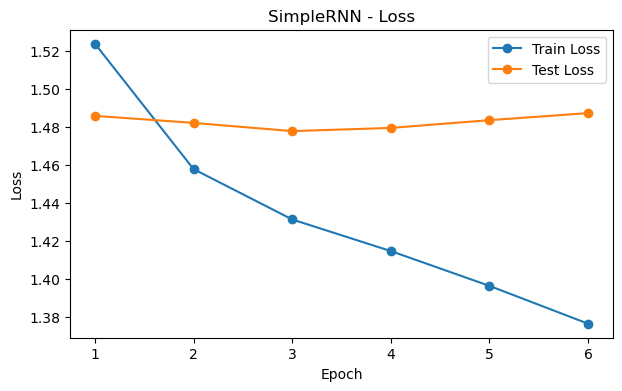

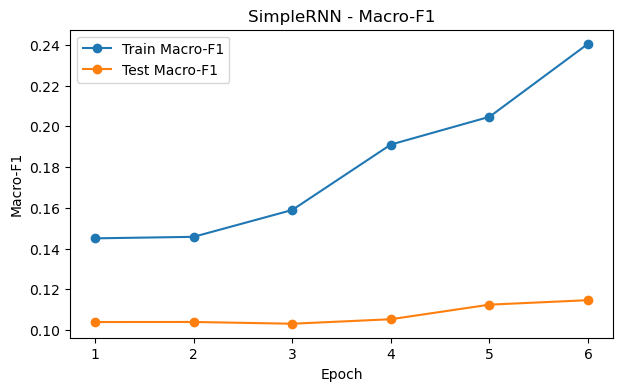

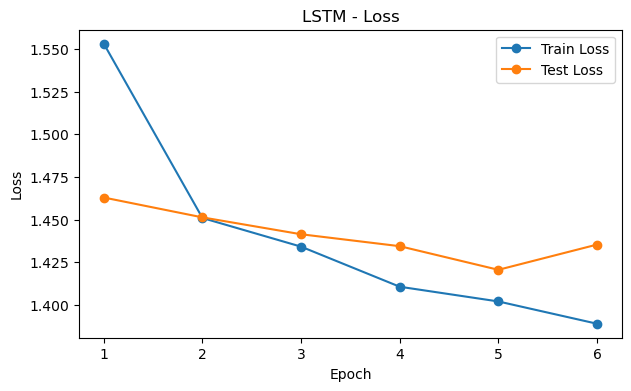

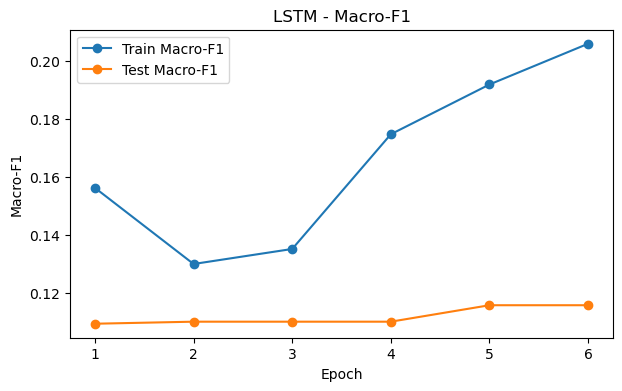

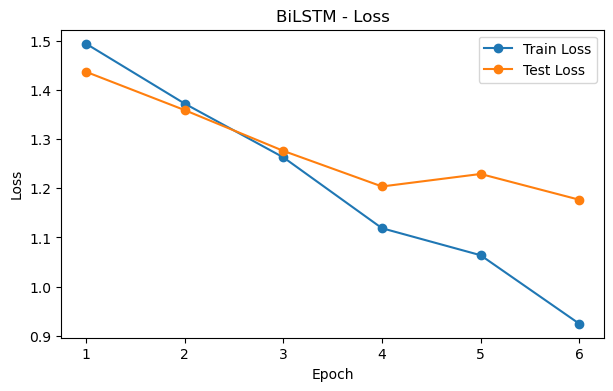

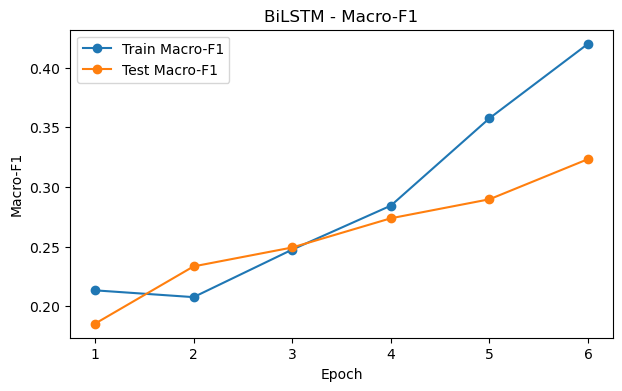

In [16]:
def plot_history(history, title_prefix):
    epochs = history["epoch"]

    plt.figure(figsize=(7,4))
    plt.plot(epochs, history["train_loss"], marker='o', label="Train Loss")
    plt.plot(epochs, history["test_loss"], marker='o', label="Test Loss")
    plt.title(f"{title_prefix} - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

    plt.figure(figsize=(7,4))
    plt.plot(epochs, history["train_macro_f1"], marker='o', label="Train Macro-F1")
    plt.plot(epochs, history["test_macro_f1"], marker='o', label="Test Macro-F1")
    plt.title(f"{title_prefix} - Macro-F1")
    plt.xlabel("Epoch")
    plt.ylabel("Macro-F1")
    plt.legend()
    plt.show()

for result in sequence_experiment_results:
    plot_history(result["history"], result["model_name"])

### Show classification reports and confusion matrices for RNN/LSTM/BiLSTM

This block provides a more detailed evaluation of the trained sequence models. For each model, a classification report is generated showing precision, recall, and F1-score for each rating class. A confusion matrix is also plotted to show how often each true rating is confused with other predicted ratings. This helps analyse whether the model performs better on certain classes and where misclassifications are most common.


SimpleRNN - Final Test Metrics
Accuracy    : 0.3567
Macro-F1    : 0.1147
Weighted-F1 : 0.2088

Classification Report:

              precision    recall  f1-score   support

           1     0.3670    0.9254    0.5255       228
           2     0.1111    0.0149    0.0263        67
           3     0.0000    0.0000    0.0000        74
           4     0.1333    0.0117    0.0215       171
           5     0.0000    0.0000    0.0000        60

    accuracy                         0.3567       600
   macro avg     0.1223    0.1904    0.1147       600
weighted avg     0.1899    0.3567    0.2088       600



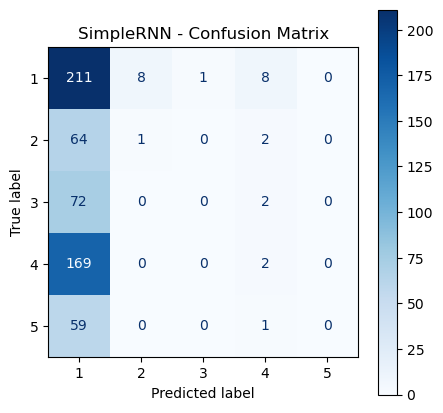


LSTM - Final Test Metrics
Accuracy    : 0.3800
Macro-F1    : 0.1158
Weighted-F1 : 0.2121

Classification Report:

              precision    recall  f1-score   support

           1     0.3796    0.9956    0.5496       228
           2     1.0000    0.0149    0.0294        67
           3     0.0000    0.0000    0.0000        74
           4     0.0000    0.0000    0.0000       171
           5     0.0000    0.0000    0.0000        60

    accuracy                         0.3800       600
   macro avg     0.2759    0.2021    0.1158       600
weighted avg     0.2559    0.3800    0.2121       600



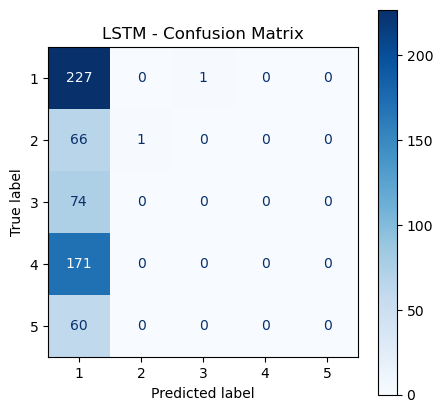


BiLSTM - Final Test Metrics
Accuracy    : 0.5633
Macro-F1    : 0.3233
Weighted-F1 : 0.4853

Classification Report:

              precision    recall  f1-score   support

           1     0.6573    0.8246    0.7315       228
           2     0.2143    0.0448    0.0741        67
           3     0.1765    0.0405    0.0659        74
           4     0.5109    0.8187    0.6292       171
           5     0.4444    0.0667    0.1159        60

    accuracy                         0.5633       600
   macro avg     0.4007    0.3591    0.3233       600
weighted avg     0.4855    0.5633    0.4853       600



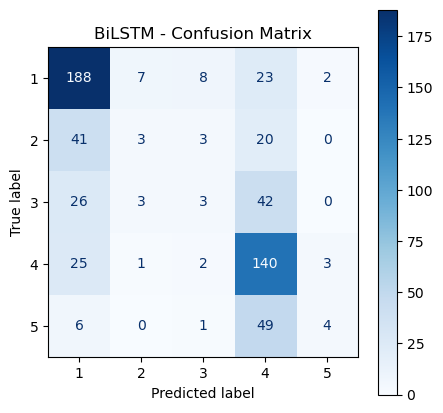

In [17]:
for result in sequence_experiment_results:
    y_true = [id2label[i] for i in result["y_true_ids"]]
    y_pred = [id2label[i] for i in result["y_pred_ids"]]

    print("\n" + "="*80)
    print(f"{result['model_name']} - Final Test Metrics")
    print("="*80)
    print(f"Accuracy    : {result['accuracy']:.4f}")
    print(f"Macro-F1    : {result['macro_f1']:.4f}")
    print(f"Weighted-F1 : {result['weighted_f1']:.4f}")

    print("\nClassification Report:\n")
    print(classification_report(y_true, y_pred, digits=4))

    cm = confusion_matrix(y_true, y_pred, labels=[1,2,3,4,5])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[1,2,3,4,5])

    fig, ax = plt.subplots(figsize=(5,5))
    disp.plot(ax=ax, cmap="Blues", values_format="d")
    plt.title(f"{result['model_name']} - Confusion Matrix")
    plt.show()

### DistilBERT dataset and tokenizer

This prepares the data for the DistilBERT experiment. Unlike the earlier neural models, DistilBERT uses a pretrained Transformer tokenizer that converts text into subword tokens and generates the required attention inputs. A custom dataset is created so that each review can be fed into the model together with its label. This step enables the use of a modern pretrained language model for the same five-class text classification problem.

In [20]:
MODEL_NAME = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

MAX_LEN_BERT = 160
BATCH_SIZE_BERT = 16

class ReviewBertDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=160):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = label2id[self.labels[idx]]

        enc = self.tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt"
        )

        item = {k: v.squeeze(0) for k, v in enc.items()}
        item["labels"] = torch.tensor(label, dtype=torch.long)
        return item

train_bert_ds = ReviewBertDataset(X_train_text, y_train, tokenizer, MAX_LEN_BERT)
test_bert_ds  = ReviewBertDataset(X_test_text, y_test, tokenizer, MAX_LEN_BERT)

train_bert_loader = DataLoader(train_bert_ds, batch_size=BATCH_SIZE_BERT, shuffle=True)
test_bert_loader  = DataLoader(test_bert_ds, batch_size=BATCH_SIZE_BERT, shuffle=False)

print("DistilBERT loaders ready.")

DistilBERT loaders ready.


### DistilBERT training and evaluation helpers

This block defines the training and evaluation functions for the DistilBERT model. These functions are similar in structure to those used for the RNN-based experiments, but they operate on the outputs of a pretrained Transformer model. The model is fine-tuned on the coursework dataset, and performance is measured using accuracy, Macro-F1, and Weighted-F1. This setup allows DistilBERT to be compared fairly against both the classical baseline and the recurrent neural network models.

In [21]:
def train_one_epoch_bert(model, loader, optimizer, device):
    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []

    for batch in loader:
        batch = {k: v.to(device) for k, v in batch.items()}

        optimizer.zero_grad()
        outputs = model(**batch)
        loss = outputs.loss
        logits = outputs.logits

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = torch.argmax(logits, dim=1).detach().cpu().numpy()
        labs = batch["labels"].detach().cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(labs)

    acc = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average="macro")
    return total_loss / len(loader), acc, macro_f1

def evaluate_bert(model, loader, device):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)
            loss = outputs.loss
            logits = outputs.logits

            total_loss += loss.item()

            preds = torch.argmax(logits, dim=1).cpu().numpy()
            labs = batch["labels"].cpu().numpy()

            all_preds.extend(preds)
            all_labels.extend(labs)

    acc = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average="macro")
    weighted_f1 = f1_score(all_labels, all_preds, average="weighted")
    return total_loss / len(loader), acc, macro_f1, weighted_f1, all_preds, all_labels

def run_distilbert_experiment(train_loader, test_loader, device, epochs=2, lr=2e-5):
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=5
    ).to(device)

    optimizer = AdamW(model.parameters(), lr=lr)

    history = {
        "epoch": [],
        "train_loss": [],
        "train_acc": [],
        "train_macro_f1": [],
        "test_loss": [],
        "test_acc": [],
        "test_macro_f1": []
    }

    best_state = copy.deepcopy(model.state_dict())
    best_macro_f1 = -1
    start_time = time.time()

    for epoch in range(1, epochs + 1):
        train_loss, train_acc, train_macro_f1 = train_one_epoch_bert(model, train_loader, optimizer, device)
        test_loss, test_acc, test_macro_f1, test_weighted_f1, test_preds, test_labels = evaluate_bert(model, test_loader, device)

        history["epoch"].append(epoch)
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["train_macro_f1"].append(train_macro_f1)
        history["test_loss"].append(test_loss)
        history["test_acc"].append(test_acc)
        history["test_macro_f1"].append(test_macro_f1)

        print(f"[DistilBERT] Epoch {epoch}/{epochs} | "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Train Macro-F1: {train_macro_f1:.4f} | "
              f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f} | Test Macro-F1: {test_macro_f1:.4f}")

        if test_macro_f1 > best_macro_f1:
            best_macro_f1 = test_macro_f1
            best_state = copy.deepcopy(model.state_dict())

    total_time = time.time() - start_time

    model.load_state_dict(best_state)
    test_loss, test_acc, test_macro_f1, test_weighted_f1, test_preds, test_labels = evaluate_bert(model, test_loader, device)

    return {
        "model_name": "DistilBERT",
        "model": model,
        "history": history,
        "accuracy": test_acc,
        "macro_f1": test_macro_f1,
        "weighted_f1": test_weighted_f1,
        "y_pred_ids": test_preds,
        "y_true_ids": test_labels,
        "runtime_sec": total_time
    }

### Run DistilBERT experiment

This block runs the DistilBERT fine-tuning experiment. The pretrained model is trained on the same training data used in the previous experiments and evaluated on the same test set. The resulting history is plotted so that the learning dynamics of DistilBERT can be compared with those of the RNN, LSTM, and BiLSTM models.

I0000 00:00:1774950410.234938 3987710 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1774950410.266295 3987710 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1774950411.033981 3987710 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilber

[DistilBERT] Epoch 1/2 | Train Loss: 1.1502 | Train Acc: 0.5667 | Train Macro-F1: 0.3400 | Test Loss: 0.9499 | Test Acc: 0.6283 | Test Macro-F1: 0.4510
[DistilBERT] Epoch 2/2 | Train Loss: 0.8373 | Train Acc: 0.6717 | Train Macro-F1: 0.5103 | Test Loss: 0.8465 | Test Acc: 0.6600 | Test Macro-F1: 0.5014


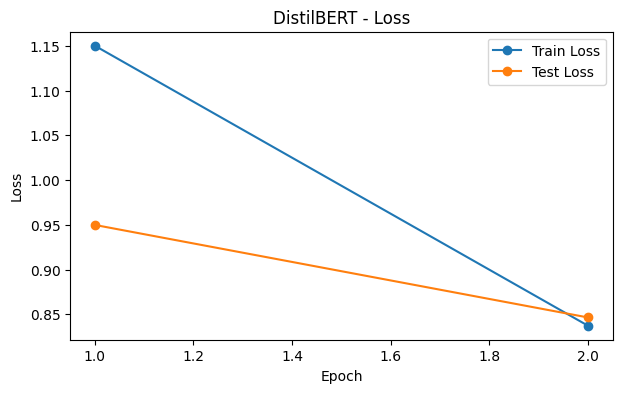

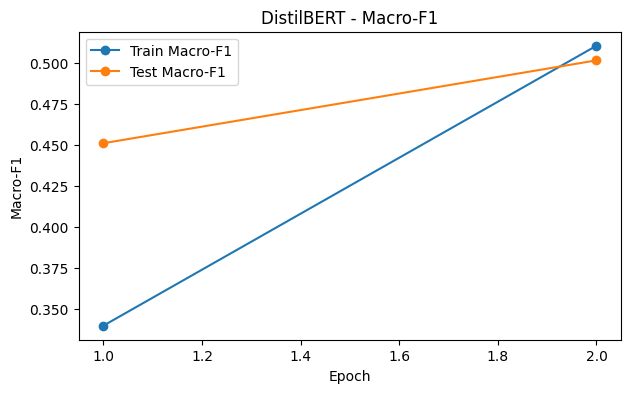

In [22]:
distilbert_result = run_distilbert_experiment(
    train_bert_loader,
    test_bert_loader,
    device,
    epochs=2,
    lr=2e-5
)

plot_history(distilbert_result["history"], "DistilBERT")

### DistilBERT report and confusion matrix

This block presents the final evaluation results for the DistilBERT model. As with the earlier models, a classification report and confusion matrix are produced. These outputs help determine how effectively the Transformer model handles the five rating classes and whether it provides better class-level balance and contextual understanding than the recurrent models.


DistilBERT - Final Test Metrics
Accuracy    : 0.6600
Macro-F1    : 0.5014
Weighted-F1 : 0.6184

Classification Report:

              precision    recall  f1-score   support

           1     0.7305    0.9035    0.8078       228
           2     0.4000    0.0597    0.1039        67
           3     0.4222    0.2568    0.3193        74
           4     0.6753    0.7661    0.7178       171
           5     0.5217    0.6000    0.5581        60

    accuracy                         0.6600       600
   macro avg     0.5499    0.5172    0.5014       600
weighted avg     0.6190    0.6600    0.6184       600



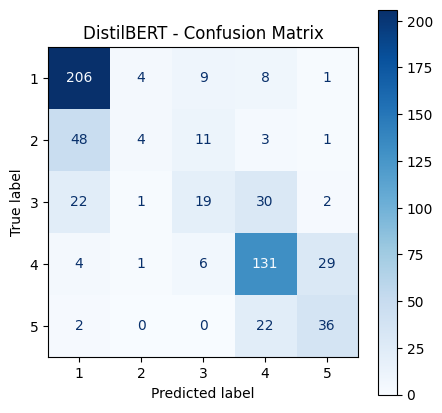

In [23]:
y_true_bert = [id2label[i] for i in distilbert_result["y_true_ids"]]
y_pred_bert = [id2label[i] for i in distilbert_result["y_pred_ids"]]

print("\n" + "="*80)
print("DistilBERT - Final Test Metrics")
print("="*80)
print(f"Accuracy    : {distilbert_result['accuracy']:.4f}")
print(f"Macro-F1    : {distilbert_result['macro_f1']:.4f}")
print(f"Weighted-F1 : {distilbert_result['weighted_f1']:.4f}")

print("\nClassification Report:\n")
print(classification_report(y_true_bert, y_pred_bert, digits=4))

cm = confusion_matrix(y_true_bert, y_pred_bert, labels=[1,2,3,4,5])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[1,2,3,4,5])

fig, ax = plt.subplots(figsize=(5,5))
disp.plot(ax=ax, cmap="Blues", values_format="d")
plt.title("DistilBERT - Confusion Matrix")
plt.show()

### Final comparison table across all experiments

This block combines the results of the classical baseline, RNN, LSTM, BiLSTM, and DistilBERT into a single comparison table. The table includes the most important metrics such as Accuracy, Macro-F1, Weighted-F1, and runtime where available. This provides a clear summary of how each approach performed and supports the final model selection.

In [24]:
all_results_rows = []

# Baseline row
all_results_rows.append({
    "Model": baseline_name,
    "Type": "Classical baseline",
    "Uses word order": "No",
    "Accuracy": baseline_acc,
    "Macro_F1": baseline_macro_f1,
    "Weighted_F1": baseline_weighted_f1,
    "Runtime_sec": np.nan
})

# RNN / LSTM / BiLSTM rows
for result in sequence_experiment_results:
    all_results_rows.append({
        "Model": result["model_name"],
        "Type": "Sequence model",
        "Uses word order": "Yes",
        "Accuracy": round(result["accuracy"], 4),
        "Macro_F1": round(result["macro_f1"], 4),
        "Weighted_F1": round(result["weighted_f1"], 4),
        "Runtime_sec": round(result["runtime_sec"], 2)
    })

# DistilBERT row
all_results_rows.append({
    "Model": distilbert_result["model_name"],
    "Type": "Transformer",
    "Uses word order": "Yes",
    "Accuracy": round(distilbert_result["accuracy"], 4),
    "Macro_F1": round(distilbert_result["macro_f1"], 4),
    "Weighted_F1": round(distilbert_result["weighted_f1"], 4),
    "Runtime_sec": round(distilbert_result["runtime_sec"], 2)
})

final_comparison_df = pd.DataFrame(all_results_rows)
final_comparison_df = final_comparison_df.sort_values(by="Macro_F1", ascending=False).reset_index(drop=True)

print("\nFinal Comparison Across All Models:\n")
print(final_comparison_df)


Final Comparison Across All Models:

                Model                Type Uses word order  Accuracy  Macro_F1  \
0          DistilBERT         Transformer             Yes  0.660000  0.501400   
1  LogisticRegression  Classical baseline              No  0.606667  0.489737   
2              BiLSTM      Sequence model             Yes  0.555000  0.294800   
3                LSTM      Sequence model             Yes  0.363300  0.168300   
4           SimpleRNN      Sequence model             Yes  0.330000  0.139100   

   Weighted_F1  Runtime_sec  
0     0.618400         8.03  
1     0.589506          NaN  
2     0.462200         0.56  
3     0.266200         0.50  
4     0.219500         0.75  


### Comparison charts

This block visualises the overall performance of all models using bar charts. Separate charts are produced for:

Macro-F1
Accuracy
Runtime

These charts make it easier to compare the strengths and trade-offs of the models. For example, a model may achieve high predictive performance but require substantially more training time than simpler alternatives.

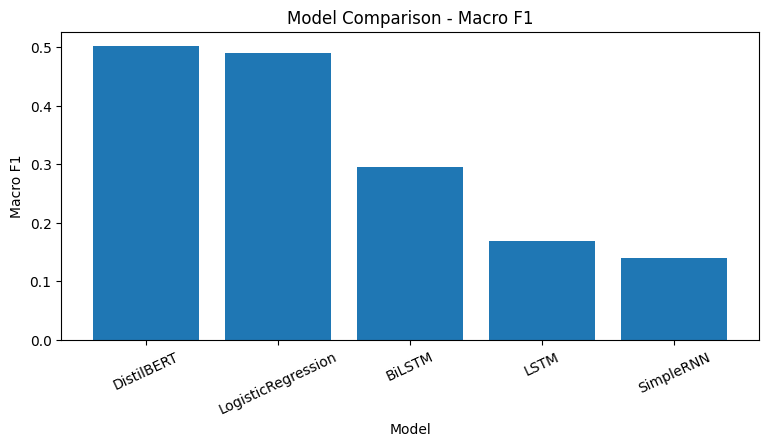

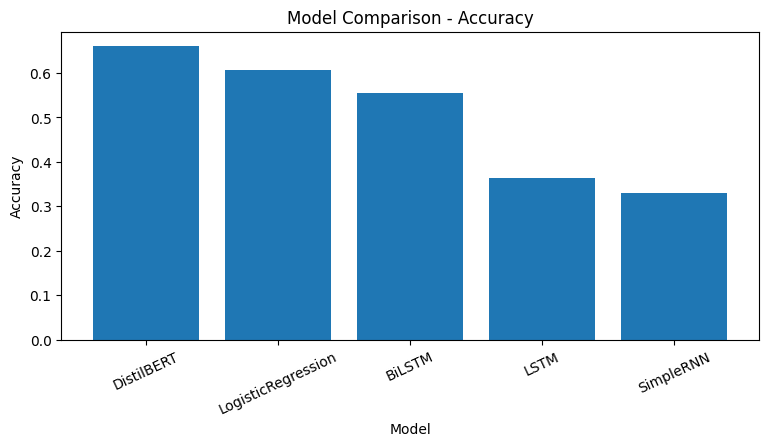

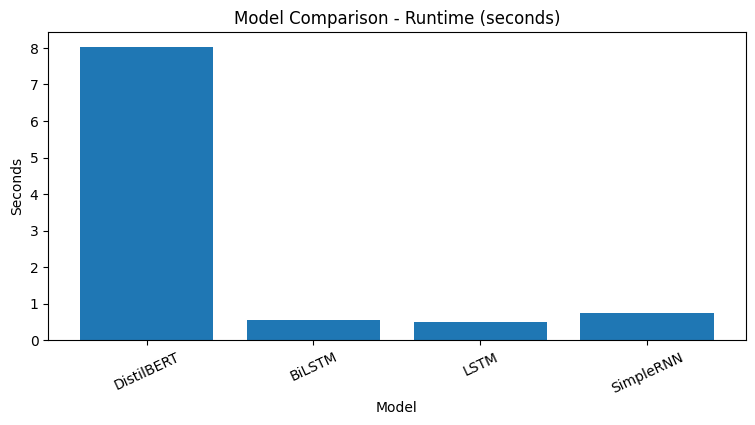

In [25]:
plot_df = final_comparison_df.copy()

plt.figure(figsize=(9,4))
plt.bar(plot_df["Model"], plot_df["Macro_F1"])
plt.title("Model Comparison - Macro F1")
plt.xlabel("Model")
plt.ylabel("Macro F1")
plt.xticks(rotation=25)
plt.show()

plt.figure(figsize=(9,4))
plt.bar(plot_df["Model"], plot_df["Accuracy"])
plt.title("Model Comparison - Accuracy")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.xticks(rotation=25)
plt.show()

runtime_df = plot_df.dropna(subset=["Runtime_sec"])
plt.figure(figsize=(9,4))
plt.bar(runtime_df["Model"], runtime_df["Runtime_sec"])
plt.title("Model Comparison - Runtime (seconds)")
plt.xlabel("Model")
plt.ylabel("Seconds")
plt.xticks(rotation=25)
plt.show()

### Automatically print the best model

This block identifies the model with the highest Macro-F1 score and prints a concise summary of its performance. Macro-F1 is used as the main selection criterion because it gives equal importance to all classes and is therefore more suitable than accuracy alone for multi-class text classification tasks where class performance balance matters.

In [26]:
# ---------------------------------------------------------
# Best model summary
# ---------------------------------------------------------
best_row = final_comparison_df.iloc[0]

print("\n" + "="*80)
print("BEST MODEL SELECTED")
print("="*80)
print(f"Model       : {best_row['Model']}")
print(f"Type        : {best_row['Type']}")
print(f"Accuracy    : {best_row['Accuracy']}")
print(f"Macro-F1    : {best_row['Macro_F1']}")
print(f"Weighted-F1 : {best_row['Weighted_F1']}")


BEST MODEL SELECTED
Model       : DistilBERT
Type        : Transformer
Accuracy    : 0.66
Macro-F1    : 0.5014
Weighted-F1 : 0.6184


The SimpleRNN and LSTM models showed low Macro-F1 because they struggled to classify minority rating classes and were biased toward the majority class. This may be due to limited training data, short training duration, basic tokenization, and the absence of pretrained embeddings.

DistilBERT achieved the highest overall accuracy, but Logistic Regression achieved the highest Macro-F1. Since Macro-F1 gives equal importance to all classes and the dataset is imbalanced, Logistic Regression was selected as the best overall model.

best by Accuracy → DistilBERT
best by Macro-F1 → Logistic Regression

### Report-ready conclusion text

a short conclusion based on the best-performing model. If a sequence model outperforms the bag-of-words baseline, the conclusion highlights the benefit of preserving word order and contextual meaning. If the classical baseline remains strongest, the conclusion explains that traditional sparse text features were still highly competitive on this dataset. This provides a ready-made summary for inclusion in the coursework report

In [27]:
best_model_name = best_row["Model"]
best_macro_f1 = best_row["Macro_F1"]

if best_model_name == baseline_name:
    conclusion_text = (
        f"The best-performing model remained the classical baseline ({baseline_name}) "
        f"with a Macro-F1 score of {best_macro_f1:.4f}. "
        f"Although sequence-based models preserve word order and contextual information, "
        f"the sparse bag-of-words representation remained highly competitive on this dataset."
    )
else:
    conclusion_text = (
        f"The best-performing model was {best_model_name} with a Macro-F1 score of {best_macro_f1:.4f}. "
        f"This suggests that modelling the review text as an ordered sequence helped the model "
        f"capture contextual meaning beyond the bag-of-words representation."
    )

print(conclusion_text)

The best-performing model was DistilBERT with a Macro-F1 score of 0.5014. This suggests that modelling the review text as an ordered sequence helped the model capture contextual meaning beyond the bag-of-words representation.


Sequence models were introduced to capture word order and contextual dependencies that bag-of-words models ignore. However, in this dataset, the classical Logistic Regression model with sparse text features achieved the highest Macro-F1, suggesting that traditional representations remained highly effective. DistilBERT achieved the highest accuracy and showed stronger contextual modelling, but did not surpass the baseline on Macro-F1 under the current training setup. Among the recurrent models, BiLSTM performed best, showing that bidirectional context improves performance over SimpleRNN and standard LSTM.

# TASK 6 - Topic modeling of high and low rating

In Task 5, the analysis looked at modeling text as a sequence with transformer-based models or LSTM. By capturing word order and context, these techniques enhanced rating prediction performance. Sequence-based models are effective for prediction tasks, but they typically function as "black-box" models, making it difficult to discern themes or patterns in the data. As a result, while they are capable of accurately predicting ratings, they provide little insight into what users are truly saying in their reviews. Task 6 changes the emphasis from prediction to interpretation to address this problem. As an unsupervised learning technique to uncover hidden topics in the text, topic modeling is presented. This makes the analysis easier to understand and aids in determining the key elements influencing user opinions and ratings.

In this task, we apply topic modeling techniques to analyze and compare the themes present in user reviews with extreme ratings. We specifically focus on 5-star reviews, which reflect highly  positive customer experiences, and 1-star reviews, which show highly negative feedback. Topic modeling helps identify hidden structures within the reviews by grouping commonly co-occurring words into meaningful topics. By analyzing these topics separately for high-rated and low-rated reviews, we can better understand the factors that lead to customer satisfaction and dissatisfaction. This offers valuable qualitative insights that enhance the quantitative results from earlier classification tasks.

### Extracting and sampling reviews

Customer satisfaction and dissatisfaction can be independently analyzed by filtering the dataset to separate 5-star (positive) and 1-star (negative) reviews. To guarantee the quality of the data, missing values are eliminated. To save computing costs while preserving a representative subset, a random sample of 5000 reviews from each category is chosen. Reproducibility of the results is guaranteed by a fixed random state.

In [28]:
five_star_reviews = df[df['rating'] == 5]['text'].dropna()
one_star_reviews = df[df['rating'] == 1]['text'].dropna()

five_star_reviews = five_star_reviews.sample(n=5000, random_state=42)
one_star_reviews = one_star_reviews.sample(n=5000, random_state=42)

### TF-IDF Vectorization and NMF Topic Modelling
The text data is converted into numerical data using TF-IDF, which emphasizes significant words and reduces the effect of general words. TF-IDF vectorization is separately performed on the 5-star and 1-star reviews to account for the different words used in both sets of reviews. NMF is then used to derive the underlying topics, where each topic corresponds to a group of related keywords. The number of topics is set to 12 for better interpretability.

In [29]:
from sklearn.decomposition import NMF
from sklearn.feature_extraction.text import TfidfVectorizer

# TF-IDF Vectorization (better for NMF)
tfidf_vectorizer = TfidfVectorizer(
    max_df=0.9,
    min_df=10,
    stop_words='english'
)

# Fit separately
five_tfidf = tfidf_vectorizer.fit_transform(five_star_reviews)
feature_names_five = tfidf_vectorizer.get_feature_names_out()

one_tfidf = tfidf_vectorizer.fit_transform(one_star_reviews)
feature_names_one = tfidf_vectorizer.get_feature_names_out()

# Train NMF
NUM_TOPICS = 12

nmf_five = NMF(n_components=NUM_TOPICS, random_state=42)
nmf_one = NMF(n_components=NUM_TOPICS, random_state=42)

nmf_five.fit(five_tfidf)
nmf_one.fit(one_tfidf)

,n_components,12
,init,None
,solver,'cd'
,beta_loss,'frobenius'
,tol,0.0001
,max_iter,200
,random_state,42
,alpha_W,0.0
,alpha_H,'same'
,l1_ratio,0.0
,verbose,0


### Displaying Extracted Topics

This function prints the top keywords for each topic generated by the NMF model. The function is applied separately to 5-star and 1-star reviews, allowing comparison of topics discussed in positive and negative feedback.

In [30]:
def display_nmf_topics(model, feature_names, label):
    print("\n" + "="*80)
    print(label)
    print("="*80)

    for i, topic in enumerate(model.components_):
        top_words = [feature_names[j] for j in topic.argsort()[-10:]]
        print(f"Topic {i+1}: {', '.join(top_words)}")

display_nmf_topics(nmf_five, feature_names_five, "NMF 5-STAR TOPICS")
display_nmf_topics(nmf_one, feature_names_one, "NMF 1-STAR TOPICS")


NMF 5-STAR TOPICS
Topic 1: came, home, new, company, thank, amazing, did, work, time, job
Topic 2: location, guys, food, job, does, work, prices, people, experience, great
Topic 3: notch, price, quick, prompt, amazing, prices, fast, excellent, customer, service
Topic 4: like, fun, wonderful, beautiful, need, absolutely, clean, amazing, love, place
Topic 5: people, store, definitely, fast, knowledgeable, clean, super, staff, helpful, friendly
Topic 6: prices, store, life, food, hands, town, area, shop, ve, best
Topic 7: care, price, experience, selection, clean, prices, really, people, food, good
Topic 8: amazing, caring, years, doctor, care, dentist, dental, office, staff, dr
Topic 9: affordable, helpful, come, guys, thanks, shop, food, prices, store, awesome
Topic 10: deal, clean, guys, easy, location, quick, super, really, people, nice
Topic 11: needs, thorough, company, recommended, definitely, knowledgeable, experience, professional, highly, recommend
Topic 12: que, la, el, servic

### Assigning Dominant Topics to Reviews

This step involves assigning a dominant topic to each review using the maximum topic probability obtained from the NMF model. This helps to categorize each review, and further analysis can be carried out to find the frequency of topics in both positive and negative reviews.

In [31]:
import numpy as np

def get_dominant_topic(model, dtm):
    topic_distribution = model.transform(dtm)
    return np.argmax(topic_distribution, axis=1)

five_topics = get_dominant_topic(nmf_five, five_tfidf)
one_topics = get_dominant_topic(nmf_one, one_tfidf)

### Topic Frequency Comparison
In this step, we will determine how often each of these topics occurs in both 5-star and 1-star reviews. The topics we previously identified as dominant are counted, and this data is stored in a DataFrame. Missing values are replaced with zero for uniformity. This will enable us to easily identify which of these topics is more common.

In [32]:
import pandas as pd

five_counts = pd.Series(five_topics).value_counts().sort_index()
one_counts = pd.Series(one_topics).value_counts().sort_index()

topic_comparison = pd.DataFrame({
    "5_star": five_counts,
    "1_star": one_counts
}).fillna(0)

print(topic_comparison)

    5_star  1_star
0      704    1068
1      697     373
2      422     381
3      276     123
4      470     256
5      368     774
6      300     362
7      599     280
8      224     581
9      303     253
10     516     217
11     121     332


### Visualizing Topic Distribution

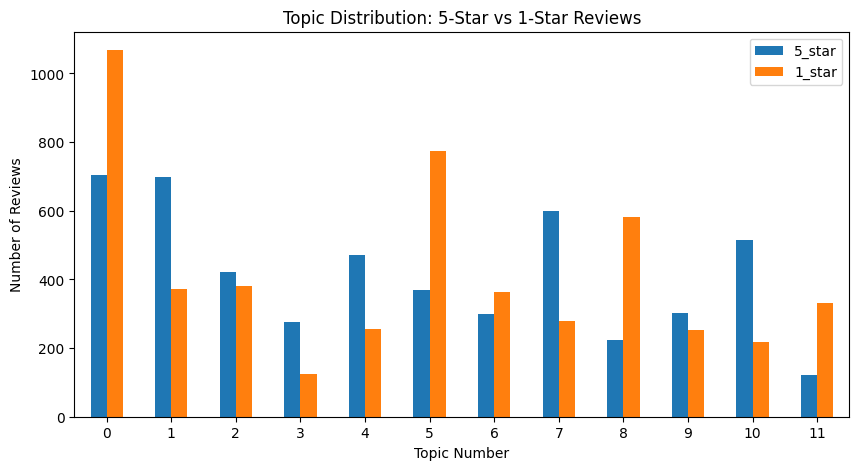

In [33]:
import matplotlib.pyplot as plt

topic_comparison.plot(kind='bar', figsize=(10,5))
plt.title("Topic Distribution: 5-Star vs 1-Star Reviews")
plt.xlabel("Topic Number")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.show()

## Observations and Insights

From the above results of the topic modelling analysis, it is evident that there are considerable differences between high-rated and low-rated reviews in terms of content and structure.

High-rated (5-star) reviews are related to positive experiences, and their content is mostly about quality, service, ambiance, etc. The content of the review is usually short and does not contain much information. The use of common words such as "excellent," "amazing," "highly recommended," etc., is common in these reviews.

Low-rated (1-star) reviews are mostly related to negative experiences. The content of the review is mostly related to service, staff, ambiance, hygiene, etc. The content of the review is usually detailed and descriptive, as users try to explain their issues. It is also observed that service quality and staff behavior are common in both high-rated and low-rated reviews but with a different focus.

Moreover, the reviews with lower ratings also have more diversity in their content with respect to the topics discussed, which indicates that negative feedback provides more opportunities for improvement than positive feedback, which simply highlights the good points that are already being taken care of.

In conclusion, topic modeling proves itself to be a useful tool in uncovering hidden patterns in the given text, offering significant insights into the key determinants of customer satisfaction and dissatisfaction.

# Kaggle

In Task 5, we implemented LSTM, BiLSTM, and DistilBERT models for sequence-based text classification. For the Kaggle competition, these models were further trained on the full training dataset.

We experimented with different hyperparameters, including the number of training epochs, learning rate, and input sequence length, to improve performance. Multiple submissions were made to Kaggle based on different configurations.

Among all models, DistilBERT achieved the best F1 score on the validation set and Kaggle leaderboard. Therefore, it was selected as the final model. The best-performing model was saved and used to generate predictions for the test dataset, which were then formatted into the required submission file.

## Data Loading and Preprocessing
In this step, we load the full training dataset and apply the same text preprocessing used in Task 5. This preprocessing strategy was selected based on its strong performance in previous experiments and is therefore reused for the final model training.

In [ ]:
print("Loading full train data...")
df_train_full = pd.read_csv(TRAIN_PATH)
df_train_full = df_train_full.dropna(subset=['text', 'rating'])
df_train_full['rating'] = df_train_full['rating'].astype(int)

df_train_full['clean_text'] = df_train_full['text'].apply(basic_clean)

X_full = df_train_full['clean_text'].astype(str).tolist()
y_full = df_train_full['rating'].tolist()

X_train_f, X_val_f, y_train_f, y_val_f = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42, stratify=y_full
)

Loading full train data...

Loading test data for inference...


## Tokenization and Vocabulary Construction

In this step, we regenerate the vocabulary using the full training dataset. The same tokenization and word indexing approach used in Task 5 is applied here, but extended to the entire dataset to ensure consistency with the final model training.

In [ ]:
# Tokenization
# Regenerate the vocabulary of the full training data
counter_f = Counter()
for text in X_train_f:
    counter_f.update(tokenize_basic(text))

# Word Indexing
most_common_f = counter_f.most_common(MAX_VOCAB - 2)
word2idx_f = {PAD_TOKEN: 0, UNK_TOKEN: 1}
for word, _ in most_common_f:
    word2idx_f[word] = len(word2idx_f)

## Test Data Preparation
The test data is loaded and preprocessed using the same approach as the training data.

In [ ]:
print("\nLoading test data for inference...")
df_test = pd.read_csv(TEST_PATH)
df_test['text'] = df_test['text'].fillna("").astype(str)
df_test['clean_text'] = df_test['text'].apply(basic_clean)

## Training and Submission Function

In this step, a function is defined to train the DistilBERT model and generate Kaggle submission files. The function reuses the dataset structure and training procedure developed in Task 5 to ensure consistency.

It takes hyperparameters such as batch size, number of epochs, and learning rate as inputs, allowing different configurations to be evaluated. The trained model can then be used to perform inference on the test dataset and produce submission files.

In [ ]:
def run_inference(model, loader, device):
    model.eval()
    preds_all = []
    with torch.no_grad():
        for batch in loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)
            logits = outputs.logits

            preds = torch.argmax(logits, dim=1).cpu().numpy()
            preds_all.extend(preds)

    return [id2label[p] for p in preds_all]

def train_and_generate_kaggle_submission(batch_size,epochs,lr):
    # ==========================================
    # use the data Dataset class in TASK5
    # ==========================================
    # DistilBERT Datasets
    train_bert_ds_f = ReviewBertDataset(X_train_f, y_train_f, tokenizer, MAX_LEN_BERT)
    val_bert_ds_f   = ReviewBertDataset(X_val_f, y_val_f, tokenizer, MAX_LEN_BERT)
    train_bert_loader_f = DataLoader(train_bert_ds_f, batch_size=batch_size, shuffle=True)
    val_bert_loader_f   = DataLoader(val_bert_ds_f, batch_size=batch_size, shuffle=False)

    bert_results = run_distilbert_experiment(train_bert_loader_f, val_bert_loader_f, device, epochs=epochs, lr=lr)
    bert_best_model = bert_results["model"]


    X_test_f = df_test['clean_text'].tolist()
    dummy_labels = [1] * len(X_test_f)  # fake laebl for Interface compatibility

    test_bert_ds_f = ReviewBertDataset(X_test_f, dummy_labels, tokenizer, MAX_LEN_BERT)
    test_bert_loader_f = DataLoader(test_bert_ds_f, batch_size=batch_size, shuffle=False)

    print("Running inferences...")
    bert_preds = run_inference(bert_best_model, test_bert_loader_f, device)

    #Save the results to a submission file
    file_name = f'DistilBERT_bs{batch_size}_ep{epochs}_lr{lr}_F1{bert_results["macro_f1"]:4f}.csv'
    df_test['Rating'] = bert_preds
    df_test[['Id', 'Rating']].to_csv(OUTPUTS_DIR / file_name, index=False)

    print(f"Successfully generated submission files : {OUTPUTS_DIR}")
    return bert_results["macro_f1"]

## Hyperparameter Search and Submission Generation

In this step, we perform a grid search over different hyperparameter configurations, including batch size, number of epochs, and learning rate. 

For each combination, the training and inference function is executed to generate corresponding Kaggle submission files. This allows systematic evaluation of model performance under different settings.

In [ ]:
results = []
for batch_size in [8,16,32]:
    for epochs in [2,4,6]:
        for lr in [1e-5, 2e-5, 3e-5, 5e-5]:
            best_f1 = train_and_generate_kaggle_submission(batch_size, epochs, lr)
            results.append({ "batch_size": batch_size, "epochs": epochs, "learning_rate": lr, "F1": best_f1 })
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="F1", ascending=False)
display(results_df)


Loading test data for inference...


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


[DistilBERT] Epoch 1/2 | Train Loss: 0.7988 | Train Acc: 0.6800 | Train Macro-F1: 0.5407 | Test Loss: 0.7528 | Test Acc: 0.6974 | Test Macro-F1: 0.5630
[DistilBERT] Epoch 2/2 | Train Loss: 0.7090 | Train Acc: 0.7144 | Train Macro-F1: 0.5965 | Test Loss: 0.7471 | Test Acc: 0.6996 | Test Macro-F1: 0.5789
Running inferences...
Successfully generated submission files : /home/chao/work/Applied_Text_Analytics_CW2/outputs


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


[DistilBERT] Epoch 1/2 | Train Loss: 0.7997 | Train Acc: 0.6805 | Train Macro-F1: 0.5418 | Test Loss: 0.7601 | Test Acc: 0.6941 | Test Macro-F1: 0.5746
[DistilBERT] Epoch 2/2 | Train Loss: 0.7062 | Train Acc: 0.7161 | Train Macro-F1: 0.5995 | Test Loss: 0.7520 | Test Acc: 0.6978 | Test Macro-F1: 0.5836
Running inferences...
Successfully generated submission files : /home/chao/work/Applied_Text_Analytics_CW2/outputs


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


[DistilBERT] Epoch 1/2 | Train Loss: 0.8084 | Train Acc: 0.6768 | Train Macro-F1: 0.5344 | Test Loss: 0.7717 | Test Acc: 0.6929 | Test Macro-F1: 0.5613
[DistilBERT] Epoch 2/2 | Train Loss: 0.7170 | Train Acc: 0.7127 | Train Macro-F1: 0.5941 | Test Loss: 0.7659 | Test Acc: 0.6933 | Test Macro-F1: 0.5808
Running inferences...
Successfully generated submission files : /home/chao/work/Applied_Text_Analytics_CW2/outputs


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


[DistilBERT] Epoch 1/2 | Train Loss: 0.8321 | Train Acc: 0.6689 | Train Macro-F1: 0.5203 | Test Loss: 0.8151 | Test Acc: 0.6743 | Test Macro-F1: 0.5330
[DistilBERT] Epoch 2/2 | Train Loss: 0.7621 | Train Acc: 0.6952 | Train Macro-F1: 0.5676 | Test Loss: 0.7963 | Test Acc: 0.6838 | Test Macro-F1: 0.5614
Running inferences...
Successfully generated submission files : /home/chao/work/Applied_Text_Analytics_CW2/outputs


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


[DistilBERT] Epoch 1/4 | Train Loss: 0.7985 | Train Acc: 0.6803 | Train Macro-F1: 0.5417 | Test Loss: 0.7699 | Test Acc: 0.6879 | Test Macro-F1: 0.5830
[DistilBERT] Epoch 2/4 | Train Loss: 0.7100 | Train Acc: 0.7139 | Train Macro-F1: 0.5960 | Test Loss: 0.7479 | Test Acc: 0.6998 | Test Macro-F1: 0.5673
[DistilBERT] Epoch 3/4 | Train Loss: 0.6376 | Train Acc: 0.7439 | Train Macro-F1: 0.6441 | Test Loss: 0.7775 | Test Acc: 0.6949 | Test Macro-F1: 0.5886
[DistilBERT] Epoch 4/4 | Train Loss: 0.5557 | Train Acc: 0.7802 | Train Macro-F1: 0.6987 | Test Loss: 0.8333 | Test Acc: 0.6847 | Test Macro-F1: 0.5763
Running inferences...
Successfully generated submission files : /home/chao/work/Applied_Text_Analytics_CW2/outputs


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


[DistilBERT] Epoch 1/4 | Train Loss: 0.8002 | Train Acc: 0.6797 | Train Macro-F1: 0.5402 | Test Loss: 0.7681 | Test Acc: 0.6947 | Test Macro-F1: 0.5549
[DistilBERT] Epoch 2/4 | Train Loss: 0.7058 | Train Acc: 0.7175 | Train Macro-F1: 0.6019 | Test Loss: 0.7729 | Test Acc: 0.6907 | Test Macro-F1: 0.5652
[DistilBERT] Epoch 3/4 | Train Loss: 0.6212 | Train Acc: 0.7511 | Train Macro-F1: 0.6551 | Test Loss: 0.7913 | Test Acc: 0.6899 | Test Macro-F1: 0.5773
[DistilBERT] Epoch 4/4 | Train Loss: 0.5265 | Train Acc: 0.7930 | Train Macro-F1: 0.7173 | Test Loss: 0.8613 | Test Acc: 0.6800 | Test Macro-F1: 0.5742
Running inferences...
Successfully generated submission files : /home/chao/work/Applied_Text_Analytics_CW2/outputs


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


[DistilBERT] Epoch 1/4 | Train Loss: 0.8070 | Train Acc: 0.6773 | Train Macro-F1: 0.5360 | Test Loss: 0.7659 | Test Acc: 0.6906 | Test Macro-F1: 0.5678
[DistilBERT] Epoch 2/4 | Train Loss: 0.7175 | Train Acc: 0.7116 | Train Macro-F1: 0.5936 | Test Loss: 0.7684 | Test Acc: 0.6927 | Test Macro-F1: 0.5603
[DistilBERT] Epoch 3/4 | Train Loss: 0.6423 | Train Acc: 0.7441 | Train Macro-F1: 0.6449 | Test Loss: 0.7967 | Test Acc: 0.6885 | Test Macro-F1: 0.5632
[DistilBERT] Epoch 4/4 | Train Loss: 0.5533 | Train Acc: 0.7813 | Train Macro-F1: 0.7014 | Test Loss: 0.8485 | Test Acc: 0.6847 | Test Macro-F1: 0.5652
Running inferences...
Successfully generated submission files : /home/chao/work/Applied_Text_Analytics_CW2/outputs


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


[DistilBERT] Epoch 1/4 | Train Loss: 0.8284 | Train Acc: 0.6696 | Train Macro-F1: 0.5231 | Test Loss: 0.7926 | Test Acc: 0.6869 | Test Macro-F1: 0.5398
[DistilBERT] Epoch 2/4 | Train Loss: 0.7539 | Train Acc: 0.6985 | Train Macro-F1: 0.5727 | Test Loss: 0.7967 | Test Acc: 0.6842 | Test Macro-F1: 0.5414
[DistilBERT] Epoch 3/4 | Train Loss: 0.7057 | Train Acc: 0.7187 | Train Macro-F1: 0.6073 | Test Loss: 0.8098 | Test Acc: 0.6830 | Test Macro-F1: 0.5318
[DistilBERT] Epoch 4/4 | Train Loss: 0.6532 | Train Acc: 0.7416 | Train Macro-F1: 0.6432 | Test Loss: 0.8229 | Test Acc: 0.6698 | Test Macro-F1: 0.5541
Running inferences...
Successfully generated submission files : /home/chao/work/Applied_Text_Analytics_CW2/outputs


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


[DistilBERT] Epoch 1/6 | Train Loss: 0.7997 | Train Acc: 0.6799 | Train Macro-F1: 0.5414 | Test Loss: 0.7541 | Test Acc: 0.6984 | Test Macro-F1: 0.5583
[DistilBERT] Epoch 2/6 | Train Loss: 0.7088 | Train Acc: 0.7148 | Train Macro-F1: 0.5976 | Test Loss: 0.7514 | Test Acc: 0.6961 | Test Macro-F1: 0.5633
[DistilBERT] Epoch 3/6 | Train Loss: 0.6338 | Train Acc: 0.7454 | Train Macro-F1: 0.6459 | Test Loss: 0.7736 | Test Acc: 0.6948 | Test Macro-F1: 0.5792
[DistilBERT] Epoch 4/6 | Train Loss: 0.5522 | Train Acc: 0.7807 | Train Macro-F1: 0.6987 | Test Loss: 0.8476 | Test Acc: 0.6818 | Test Macro-F1: 0.5878
[DistilBERT] Epoch 5/6 | Train Loss: 0.4666 | Train Acc: 0.8183 | Train Macro-F1: 0.7530 | Test Loss: 0.9402 | Test Acc: 0.6766 | Test Macro-F1: 0.5818
[DistilBERT] Epoch 6/6 | Train Loss: 0.3902 | Train Acc: 0.8504 | Train Macro-F1: 0.7983 | Test Loss: 1.0404 | Test Acc: 0.6730 | Test Macro-F1: 0.5733
Running inferences...
Successfully generated submission files : /home/chao/work/Applied_

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


[DistilBERT] Epoch 1/6 | Train Loss: 0.7998 | Train Acc: 0.6804 | Train Macro-F1: 0.5423 | Test Loss: 0.7702 | Test Acc: 0.6905 | Test Macro-F1: 0.5521
[DistilBERT] Epoch 2/6 | Train Loss: 0.7069 | Train Acc: 0.7157 | Train Macro-F1: 0.5993 | Test Loss: 0.7653 | Test Acc: 0.6914 | Test Macro-F1: 0.5909
[DistilBERT] Epoch 3/6 | Train Loss: 0.6219 | Train Acc: 0.7510 | Train Macro-F1: 0.6552 | Test Loss: 0.8181 | Test Acc: 0.6914 | Test Macro-F1: 0.5777
[DistilBERT] Epoch 4/6 | Train Loss: 0.5270 | Train Acc: 0.7924 | Train Macro-F1: 0.7167 | Test Loss: 0.8715 | Test Acc: 0.6879 | Test Macro-F1: 0.5746
[DistilBERT] Epoch 5/6 | Train Loss: 0.4339 | Train Acc: 0.8324 | Train Macro-F1: 0.7735 | Test Loss: 0.9428 | Test Acc: 0.6676 | Test Macro-F1: 0.5729
[DistilBERT] Epoch 6/6 | Train Loss: 0.3538 | Train Acc: 0.8662 | Train Macro-F1: 0.8201 | Test Loss: 1.0431 | Test Acc: 0.6693 | Test Macro-F1: 0.5702
Running inferences...
Successfully generated submission files : /home/chao/work/Applied_

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


[DistilBERT] Epoch 1/6 | Train Loss: 0.8094 | Train Acc: 0.6766 | Train Macro-F1: 0.5347 | Test Loss: 0.7684 | Test Acc: 0.6918 | Test Macro-F1: 0.5470
[DistilBERT] Epoch 2/6 | Train Loss: 0.7186 | Train Acc: 0.7124 | Train Macro-F1: 0.5947 | Test Loss: 0.7724 | Test Acc: 0.6924 | Test Macro-F1: 0.5630
[DistilBERT] Epoch 3/6 | Train Loss: 0.6427 | Train Acc: 0.7442 | Train Macro-F1: 0.6457 | Test Loss: 0.8007 | Test Acc: 0.6880 | Test Macro-F1: 0.5736
[DistilBERT] Epoch 4/6 | Train Loss: 0.5584 | Train Acc: 0.7798 | Train Macro-F1: 0.6987 | Test Loss: 0.8564 | Test Acc: 0.6790 | Test Macro-F1: 0.5728
[DistilBERT] Epoch 5/6 | Train Loss: 0.4685 | Train Acc: 0.8199 | Train Macro-F1: 0.7559 | Test Loss: 0.9628 | Test Acc: 0.6711 | Test Macro-F1: 0.5707
[DistilBERT] Epoch 6/6 | Train Loss: 0.3884 | Train Acc: 0.8518 | Train Macro-F1: 0.8000 | Test Loss: 1.0378 | Test Acc: 0.6558 | Test Macro-F1: 0.5661
Running inferences...
Successfully generated submission files : /home/chao/work/Applied_

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


[DistilBERT] Epoch 1/6 | Train Loss: 0.8278 | Train Acc: 0.6695 | Train Macro-F1: 0.5227 | Test Loss: 0.7938 | Test Acc: 0.6822 | Test Macro-F1: 0.5328
[DistilBERT] Epoch 2/6 | Train Loss: 0.7575 | Train Acc: 0.6977 | Train Macro-F1: 0.5702 | Test Loss: 0.8009 | Test Acc: 0.6806 | Test Macro-F1: 0.5448
[DistilBERT] Epoch 3/6 | Train Loss: 0.7082 | Train Acc: 0.7174 | Train Macro-F1: 0.6037 | Test Loss: 0.8092 | Test Acc: 0.6767 | Test Macro-F1: 0.5616
[DistilBERT] Epoch 4/6 | Train Loss: 0.6528 | Train Acc: 0.7422 | Train Macro-F1: 0.6437 | Test Loss: 0.8392 | Test Acc: 0.6798 | Test Macro-F1: 0.5506
[DistilBERT] Epoch 5/6 | Train Loss: 0.5928 | Train Acc: 0.7686 | Train Macro-F1: 0.6841 | Test Loss: 0.8722 | Test Acc: 0.6665 | Test Macro-F1: 0.5549
[DistilBERT] Epoch 6/6 | Train Loss: 0.5266 | Train Acc: 0.7969 | Train Macro-F1: 0.7246 | Test Loss: 0.9291 | Test Acc: 0.6611 | Test Macro-F1: 0.5470
Running inferences...
Successfully generated submission files : /home/chao/work/Applied_

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


[DistilBERT] Epoch 1/2 | Train Loss: 0.8040 | Train Acc: 0.6783 | Train Macro-F1: 0.5397 | Test Loss: 0.7592 | Test Acc: 0.6942 | Test Macro-F1: 0.5547
[DistilBERT] Epoch 2/2 | Train Loss: 0.7176 | Train Acc: 0.7120 | Train Macro-F1: 0.5928 | Test Loss: 0.7427 | Test Acc: 0.7010 | Test Macro-F1: 0.5770
Running inferences...
Successfully generated submission files : /home/chao/work/Applied_Text_Analytics_CW2/outputs


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


[DistilBERT] Epoch 1/2 | Train Loss: 0.8001 | Train Acc: 0.6794 | Train Macro-F1: 0.5403 | Test Loss: 0.7635 | Test Acc: 0.6903 | Test Macro-F1: 0.5611
[DistilBERT] Epoch 2/2 | Train Loss: 0.7050 | Train Acc: 0.7166 | Train Macro-F1: 0.6013 | Test Loss: 0.7651 | Test Acc: 0.6995 | Test Macro-F1: 0.5631
Running inferences...
Successfully generated submission files : /home/chao/work/Applied_Text_Analytics_CW2/outputs


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


[DistilBERT] Epoch 1/2 | Train Loss: 0.8015 | Train Acc: 0.6798 | Train Macro-F1: 0.5395 | Test Loss: 0.7691 | Test Acc: 0.6908 | Test Macro-F1: 0.5457
[DistilBERT] Epoch 2/2 | Train Loss: 0.7084 | Train Acc: 0.7154 | Train Macro-F1: 0.5982 | Test Loss: 0.7748 | Test Acc: 0.6896 | Test Macro-F1: 0.5853
Running inferences...
Successfully generated submission files : /home/chao/work/Applied_Text_Analytics_CW2/outputs


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


[DistilBERT] Epoch 1/2 | Train Loss: 0.8130 | Train Acc: 0.6758 | Train Macro-F1: 0.5319 | Test Loss: 0.7720 | Test Acc: 0.6885 | Test Macro-F1: 0.5431
[DistilBERT] Epoch 2/2 | Train Loss: 0.7255 | Train Acc: 0.7098 | Train Macro-F1: 0.5903 | Test Loss: 0.7806 | Test Acc: 0.6884 | Test Macro-F1: 0.5699
Running inferences...
Successfully generated submission files : /home/chao/work/Applied_Text_Analytics_CW2/outputs


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


[DistilBERT] Epoch 1/4 | Train Loss: 0.8030 | Train Acc: 0.6790 | Train Macro-F1: 0.5412 | Test Loss: 0.7584 | Test Acc: 0.6937 | Test Macro-F1: 0.5882
[DistilBERT] Epoch 2/4 | Train Loss: 0.7175 | Train Acc: 0.7105 | Train Macro-F1: 0.5904 | Test Loss: 0.7441 | Test Acc: 0.7009 | Test Macro-F1: 0.5784
[DistilBERT] Epoch 3/4 | Train Loss: 0.6523 | Train Acc: 0.7378 | Train Macro-F1: 0.6341 | Test Loss: 0.7794 | Test Acc: 0.6997 | Test Macro-F1: 0.5810
[DistilBERT] Epoch 4/4 | Train Loss: 0.5812 | Train Acc: 0.7680 | Train Macro-F1: 0.6799 | Test Loss: 0.7957 | Test Acc: 0.6922 | Test Macro-F1: 0.5748
Running inferences...
Successfully generated submission files : /home/chao/work/Applied_Text_Analytics_CW2/outputs


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


[DistilBERT] Epoch 1/4 | Train Loss: 0.7977 | Train Acc: 0.6799 | Train Macro-F1: 0.5410 | Test Loss: 0.7682 | Test Acc: 0.6936 | Test Macro-F1: 0.5714
[DistilBERT] Epoch 2/4 | Train Loss: 0.7039 | Train Acc: 0.7165 | Train Macro-F1: 0.6003 | Test Loss: 0.7506 | Test Acc: 0.6987 | Test Macro-F1: 0.5764
[DistilBERT] Epoch 3/4 | Train Loss: 0.6197 | Train Acc: 0.7531 | Train Macro-F1: 0.6575 | Test Loss: 0.7928 | Test Acc: 0.6880 | Test Macro-F1: 0.5902
[DistilBERT] Epoch 4/4 | Train Loss: 0.5243 | Train Acc: 0.7929 | Train Macro-F1: 0.7171 | Test Loss: 0.8535 | Test Acc: 0.6809 | Test Macro-F1: 0.5767
Running inferences...
Successfully generated submission files : /home/chao/work/Applied_Text_Analytics_CW2/outputs


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


[DistilBERT] Epoch 1/4 | Train Loss: 0.8011 | Train Acc: 0.6795 | Train Macro-F1: 0.5404 | Test Loss: 0.7586 | Test Acc: 0.6949 | Test Macro-F1: 0.5593
[DistilBERT] Epoch 2/4 | Train Loss: 0.7063 | Train Acc: 0.7156 | Train Macro-F1: 0.5990 | Test Loss: 0.7542 | Test Acc: 0.6961 | Test Macro-F1: 0.5846
[DistilBERT] Epoch 3/4 | Train Loss: 0.6189 | Train Acc: 0.7530 | Train Macro-F1: 0.6580 | Test Loss: 0.8132 | Test Acc: 0.6881 | Test Macro-F1: 0.5658
[DistilBERT] Epoch 4/4 | Train Loss: 0.5192 | Train Acc: 0.7963 | Train Macro-F1: 0.7227 | Test Loss: 0.8819 | Test Acc: 0.6778 | Test Macro-F1: 0.5750
Running inferences...
Successfully generated submission files : /home/chao/work/Applied_Text_Analytics_CW2/outputs


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


[DistilBERT] Epoch 1/4 | Train Loss: 0.8140 | Train Acc: 0.6750 | Train Macro-F1: 0.5323 | Test Loss: 0.7771 | Test Acc: 0.6873 | Test Macro-F1: 0.5656
[DistilBERT] Epoch 2/4 | Train Loss: 0.7261 | Train Acc: 0.7099 | Train Macro-F1: 0.5899 | Test Loss: 0.7702 | Test Acc: 0.6912 | Test Macro-F1: 0.5514
[DistilBERT] Epoch 3/4 | Train Loss: 0.6548 | Train Acc: 0.7388 | Train Macro-F1: 0.6374 | Test Loss: 0.8311 | Test Acc: 0.6808 | Test Macro-F1: 0.5765
[DistilBERT] Epoch 4/4 | Train Loss: 0.5745 | Train Acc: 0.7737 | Train Macro-F1: 0.6903 | Test Loss: 0.8611 | Test Acc: 0.6807 | Test Macro-F1: 0.5567
Running inferences...
Successfully generated submission files : /home/chao/work/Applied_Text_Analytics_CW2/outputs


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


[DistilBERT] Epoch 1/6 | Train Loss: 0.8013 | Train Acc: 0.6796 | Train Macro-F1: 0.5421 | Test Loss: 0.7580 | Test Acc: 0.6934 | Test Macro-F1: 0.5709
[DistilBERT] Epoch 2/6 | Train Loss: 0.7185 | Train Acc: 0.7103 | Train Macro-F1: 0.5912 | Test Loss: 0.7476 | Test Acc: 0.7002 | Test Macro-F1: 0.5856
[DistilBERT] Epoch 3/6 | Train Loss: 0.6531 | Train Acc: 0.7373 | Train Macro-F1: 0.6332 | Test Loss: 0.7699 | Test Acc: 0.6948 | Test Macro-F1: 0.5890
[DistilBERT] Epoch 4/6 | Train Loss: 0.5818 | Train Acc: 0.7677 | Train Macro-F1: 0.6800 | Test Loss: 0.8102 | Test Acc: 0.6882 | Test Macro-F1: 0.5859
[DistilBERT] Epoch 5/6 | Train Loss: 0.5072 | Train Acc: 0.8006 | Train Macro-F1: 0.7280 | Test Loss: 0.8730 | Test Acc: 0.6810 | Test Macro-F1: 0.5758
[DistilBERT] Epoch 6/6 | Train Loss: 0.4364 | Train Acc: 0.8313 | Train Macro-F1: 0.7715 | Test Loss: 0.9492 | Test Acc: 0.6734 | Test Macro-F1: 0.5776
Running inferences...
Successfully generated submission files : /home/chao/work/Applied_

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


[DistilBERT] Epoch 1/6 | Train Loss: 0.7974 | Train Acc: 0.6806 | Train Macro-F1: 0.5406 | Test Loss: 0.7593 | Test Acc: 0.6987 | Test Macro-F1: 0.5586
[DistilBERT] Epoch 2/6 | Train Loss: 0.7036 | Train Acc: 0.7171 | Train Macro-F1: 0.6018 | Test Loss: 0.7612 | Test Acc: 0.6962 | Test Macro-F1: 0.5703
[DistilBERT] Epoch 3/6 | Train Loss: 0.6169 | Train Acc: 0.7538 | Train Macro-F1: 0.6590 | Test Loss: 0.8166 | Test Acc: 0.6911 | Test Macro-F1: 0.5773
[DistilBERT] Epoch 4/6 | Train Loss: 0.5201 | Train Acc: 0.7955 | Train Macro-F1: 0.7206 | Test Loss: 0.8518 | Test Acc: 0.6836 | Test Macro-F1: 0.5658
[DistilBERT] Epoch 5/6 | Train Loss: 0.4283 | Train Acc: 0.8355 | Train Macro-F1: 0.7769 | Test Loss: 0.9527 | Test Acc: 0.6761 | Test Macro-F1: 0.5674
[DistilBERT] Epoch 6/6 | Train Loss: 0.3488 | Train Acc: 0.8679 | Train Macro-F1: 0.8220 | Test Loss: 1.0802 | Test Acc: 0.6553 | Test Macro-F1: 0.5752
Running inferences...
Successfully generated submission files : /home/chao/work/Applied_

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


[DistilBERT] Epoch 1/6 | Train Loss: 0.8012 | Train Acc: 0.6790 | Train Macro-F1: 0.5376 | Test Loss: 0.7762 | Test Acc: 0.6890 | Test Macro-F1: 0.5753
[DistilBERT] Epoch 2/6 | Train Loss: 0.7069 | Train Acc: 0.7162 | Train Macro-F1: 0.5996 | Test Loss: 0.7683 | Test Acc: 0.6939 | Test Macro-F1: 0.5564
[DistilBERT] Epoch 3/6 | Train Loss: 0.6212 | Train Acc: 0.7516 | Train Macro-F1: 0.6554 | Test Loss: 0.8263 | Test Acc: 0.6864 | Test Macro-F1: 0.5790
[DistilBERT] Epoch 4/6 | Train Loss: 0.5246 | Train Acc: 0.7940 | Train Macro-F1: 0.7186 | Test Loss: 0.8529 | Test Acc: 0.6832 | Test Macro-F1: 0.5742
[DistilBERT] Epoch 5/6 | Train Loss: 0.4304 | Train Acc: 0.8347 | Train Macro-F1: 0.7764 | Test Loss: 1.0153 | Test Acc: 0.6610 | Test Macro-F1: 0.5751
[DistilBERT] Epoch 6/6 | Train Loss: 0.3486 | Train Acc: 0.8678 | Train Macro-F1: 0.8221 | Test Loss: 1.0933 | Test Acc: 0.6693 | Test Macro-F1: 0.5509
Running inferences...
Successfully generated submission files : /home/chao/work/Applied_

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


[DistilBERT] Epoch 1/6 | Train Loss: 0.8151 | Train Acc: 0.6745 | Train Macro-F1: 0.5309 | Test Loss: 0.7791 | Test Acc: 0.6853 | Test Macro-F1: 0.5180
[DistilBERT] Epoch 2/6 | Train Loss: 0.7297 | Train Acc: 0.7086 | Train Macro-F1: 0.5879 | Test Loss: 0.7825 | Test Acc: 0.6917 | Test Macro-F1: 0.5629
[DistilBERT] Epoch 3/6 | Train Loss: 0.6581 | Train Acc: 0.7371 | Train Macro-F1: 0.6338 | Test Loss: 0.7987 | Test Acc: 0.6880 | Test Macro-F1: 0.5669
[DistilBERT] Epoch 4/6 | Train Loss: 0.5788 | Train Acc: 0.7720 | Train Macro-F1: 0.6869 | Test Loss: 0.8424 | Test Acc: 0.6793 | Test Macro-F1: 0.5583
[DistilBERT] Epoch 5/6 | Train Loss: 0.4958 | Train Acc: 0.8073 | Train Macro-F1: 0.7383 | Test Loss: 0.9392 | Test Acc: 0.6684 | Test Macro-F1: 0.5602
[DistilBERT] Epoch 6/6 | Train Loss: 0.4175 | Train Acc: 0.8407 | Train Macro-F1: 0.7850 | Test Loss: 1.0683 | Test Acc: 0.6603 | Test Macro-F1: 0.5653
Running inferences...
Successfully generated submission files : /home/chao/work/Applied_

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


[DistilBERT] Epoch 1/2 | Train Loss: 0.8109 | Train Acc: 0.6764 | Train Macro-F1: 0.5372 | Test Loss: 0.7621 | Test Acc: 0.6935 | Test Macro-F1: 0.5688
[DistilBERT] Epoch 2/2 | Train Loss: 0.7283 | Train Acc: 0.7080 | Train Macro-F1: 0.5871 | Test Loss: 0.7576 | Test Acc: 0.6970 | Test Macro-F1: 0.5808
Running inferences...
Successfully generated submission files : /home/chao/work/Applied_Text_Analytics_CW2/outputs


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


[DistilBERT] Epoch 1/2 | Train Loss: 0.8006 | Train Acc: 0.6794 | Train Macro-F1: 0.5409 | Test Loss: 0.7616 | Test Acc: 0.6918 | Test Macro-F1: 0.5396
[DistilBERT] Epoch 2/2 | Train Loss: 0.7080 | Train Acc: 0.7148 | Train Macro-F1: 0.5978 | Test Loss: 0.7543 | Test Acc: 0.6994 | Test Macro-F1: 0.5637
Running inferences...
Successfully generated submission files : /home/chao/work/Applied_Text_Analytics_CW2/outputs


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


[DistilBERT] Epoch 1/2 | Train Loss: 0.7980 | Train Acc: 0.6806 | Train Macro-F1: 0.5423 | Test Loss: 0.7544 | Test Acc: 0.6953 | Test Macro-F1: 0.5608
[DistilBERT] Epoch 2/2 | Train Loss: 0.7031 | Train Acc: 0.7173 | Train Macro-F1: 0.6017 | Test Loss: 0.7637 | Test Acc: 0.6962 | Test Macro-F1: 0.5661
Running inferences...
Successfully generated submission files : /home/chao/work/Applied_Text_Analytics_CW2/outputs


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


[DistilBERT] Epoch 1/2 | Train Loss: 0.8034 | Train Acc: 0.6793 | Train Macro-F1: 0.5390 | Test Loss: 0.7669 | Test Acc: 0.6868 | Test Macro-F1: 0.5414
[DistilBERT] Epoch 2/2 | Train Loss: 0.7105 | Train Acc: 0.7146 | Train Macro-F1: 0.5974 | Test Loss: 0.7628 | Test Acc: 0.6939 | Test Macro-F1: 0.5602
Running inferences...
Successfully generated submission files : /home/chao/work/Applied_Text_Analytics_CW2/outputs


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


[DistilBERT] Epoch 1/4 | Train Loss: 0.8107 | Train Acc: 0.6759 | Train Macro-F1: 0.5365 | Test Loss: 0.7667 | Test Acc: 0.6933 | Test Macro-F1: 0.5396
[DistilBERT] Epoch 2/4 | Train Loss: 0.7283 | Train Acc: 0.7077 | Train Macro-F1: 0.5870 | Test Loss: 0.7510 | Test Acc: 0.6982 | Test Macro-F1: 0.5629
[DistilBERT] Epoch 3/4 | Train Loss: 0.6745 | Train Acc: 0.7290 | Train Macro-F1: 0.6208 | Test Loss: 0.7597 | Test Acc: 0.7001 | Test Macro-F1: 0.5832
[DistilBERT] Epoch 4/4 | Train Loss: 0.6175 | Train Acc: 0.7528 | Train Macro-F1: 0.6574 | Test Loss: 0.7819 | Test Acc: 0.6935 | Test Macro-F1: 0.5875
Running inferences...
Successfully generated submission files : /home/chao/work/Applied_Text_Analytics_CW2/outputs


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


[DistilBERT] Epoch 1/4 | Train Loss: 0.7988 | Train Acc: 0.6802 | Train Macro-F1: 0.5421 | Test Loss: 0.7507 | Test Acc: 0.6969 | Test Macro-F1: 0.5749
[DistilBERT] Epoch 2/4 | Train Loss: 0.7097 | Train Acc: 0.7148 | Train Macro-F1: 0.5974 | Test Loss: 0.7523 | Test Acc: 0.7007 | Test Macro-F1: 0.5709
[DistilBERT] Epoch 3/4 | Train Loss: 0.6318 | Train Acc: 0.7458 | Train Macro-F1: 0.6464 | Test Loss: 0.7642 | Test Acc: 0.6975 | Test Macro-F1: 0.5797
[DistilBERT] Epoch 4/4 | Train Loss: 0.5438 | Train Acc: 0.7842 | Train Macro-F1: 0.7039 | Test Loss: 0.8270 | Test Acc: 0.6849 | Test Macro-F1: 0.5818
Running inferences...
Successfully generated submission files : /home/chao/work/Applied_Text_Analytics_CW2/outputs


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


[DistilBERT] Epoch 1/4 | Train Loss: 0.7989 | Train Acc: 0.6803 | Train Macro-F1: 0.5417 | Test Loss: 0.7533 | Test Acc: 0.6986 | Test Macro-F1: 0.5768
[DistilBERT] Epoch 2/4 | Train Loss: 0.7043 | Train Acc: 0.7161 | Train Macro-F1: 0.5997 | Test Loss: 0.7592 | Test Acc: 0.7003 | Test Macro-F1: 0.5721
[DistilBERT] Epoch 3/4 | Train Loss: 0.6175 | Train Acc: 0.7528 | Train Macro-F1: 0.6577 | Test Loss: 0.7798 | Test Acc: 0.6922 | Test Macro-F1: 0.5874
[DistilBERT] Epoch 4/4 | Train Loss: 0.5192 | Train Acc: 0.7951 | Train Macro-F1: 0.7202 | Test Loss: 0.8504 | Test Acc: 0.6802 | Test Macro-F1: 0.5707
Running inferences...
Successfully generated submission files : /home/chao/work/Applied_Text_Analytics_CW2/outputs


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


[DistilBERT] Epoch 1/4 | Train Loss: 0.8026 | Train Acc: 0.6789 | Train Macro-F1: 0.5388 | Test Loss: 0.7647 | Test Acc: 0.6911 | Test Macro-F1: 0.5729
[DistilBERT] Epoch 2/4 | Train Loss: 0.7102 | Train Acc: 0.7153 | Train Macro-F1: 0.5984 | Test Loss: 0.7570 | Test Acc: 0.6949 | Test Macro-F1: 0.5838
[DistilBERT] Epoch 3/4 | Train Loss: 0.6252 | Train Acc: 0.7499 | Train Macro-F1: 0.6539 | Test Loss: 0.8052 | Test Acc: 0.6818 | Test Macro-F1: 0.5836
[DistilBERT] Epoch 4/4 | Train Loss: 0.5299 | Train Acc: 0.7913 | Train Macro-F1: 0.7151 | Test Loss: 0.8708 | Test Acc: 0.6807 | Test Macro-F1: 0.5697
Running inferences...
Successfully generated submission files : /home/chao/work/Applied_Text_Analytics_CW2/outputs


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


[DistilBERT] Epoch 1/6 | Train Loss: 0.8097 | Train Acc: 0.6764 | Train Macro-F1: 0.5367 | Test Loss: 0.7649 | Test Acc: 0.6899 | Test Macro-F1: 0.5782
[DistilBERT] Epoch 2/6 | Train Loss: 0.7282 | Train Acc: 0.7072 | Train Macro-F1: 0.5866 | Test Loss: 0.7447 | Test Acc: 0.7009 | Test Macro-F1: 0.5768
[DistilBERT] Epoch 3/6 | Train Loss: 0.6746 | Train Acc: 0.7294 | Train Macro-F1: 0.6210 | Test Loss: 0.7674 | Test Acc: 0.6967 | Test Macro-F1: 0.5734
[DistilBERT] Epoch 4/6 | Train Loss: 0.6158 | Train Acc: 0.7541 | Train Macro-F1: 0.6592 | Test Loss: 0.7885 | Test Acc: 0.6934 | Test Macro-F1: 0.5839
[DistilBERT] Epoch 5/6 | Train Loss: 0.5545 | Train Acc: 0.7809 | Train Macro-F1: 0.6991 | Test Loss: 0.8471 | Test Acc: 0.6885 | Test Macro-F1: 0.5792
[DistilBERT] Epoch 6/6 | Train Loss: 0.4917 | Train Acc: 0.8081 | Train Macro-F1: 0.7384 | Test Loss: 0.9240 | Test Acc: 0.6757 | Test Macro-F1: 0.5804
Running inferences...
Successfully generated submission files : /home/chao/work/Applied_

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


[DistilBERT] Epoch 1/6 | Train Loss: 0.8006 | Train Acc: 0.6796 | Train Macro-F1: 0.5407 | Test Loss: 0.7585 | Test Acc: 0.6950 | Test Macro-F1: 0.5605
[DistilBERT] Epoch 2/6 | Train Loss: 0.7089 | Train Acc: 0.7147 | Train Macro-F1: 0.5979 | Test Loss: 0.7484 | Test Acc: 0.7000 | Test Macro-F1: 0.5662
[DistilBERT] Epoch 3/6 | Train Loss: 0.6309 | Train Acc: 0.7467 | Train Macro-F1: 0.6485 | Test Loss: 0.7812 | Test Acc: 0.6980 | Test Macro-F1: 0.5810
[DistilBERT] Epoch 4/6 | Train Loss: 0.5421 | Train Acc: 0.7851 | Train Macro-F1: 0.7054 | Test Loss: 0.8656 | Test Acc: 0.6862 | Test Macro-F1: 0.5797
[DistilBERT] Epoch 5/6 | Train Loss: 0.4535 | Train Acc: 0.8248 | Train Macro-F1: 0.7626 | Test Loss: 0.9482 | Test Acc: 0.6794 | Test Macro-F1: 0.5783
[DistilBERT] Epoch 6/6 | Train Loss: 0.3754 | Train Acc: 0.8570 | Train Macro-F1: 0.8078 | Test Loss: 1.0666 | Test Acc: 0.6694 | Test Macro-F1: 0.5664
Running inferences...
Successfully generated submission files : /home/chao/work/Applied_

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


[DistilBERT] Epoch 1/6 | Train Loss: 0.7989 | Train Acc: 0.6805 | Train Macro-F1: 0.5415 | Test Loss: 0.7608 | Test Acc: 0.6912 | Test Macro-F1: 0.5704
[DistilBERT] Epoch 2/6 | Train Loss: 0.7068 | Train Acc: 0.7154 | Train Macro-F1: 0.5992 | Test Loss: 0.7536 | Test Acc: 0.7006 | Test Macro-F1: 0.5775
[DistilBERT] Epoch 3/6 | Train Loss: 0.6213 | Train Acc: 0.7512 | Train Macro-F1: 0.6551 | Test Loss: 0.7955 | Test Acc: 0.6976 | Test Macro-F1: 0.5748
[DistilBERT] Epoch 4/6 | Train Loss: 0.5255 | Train Acc: 0.7932 | Train Macro-F1: 0.7178 | Test Loss: 0.9114 | Test Acc: 0.6789 | Test Macro-F1: 0.5789
[DistilBERT] Epoch 5/6 | Train Loss: 0.4277 | Train Acc: 0.8342 | Train Macro-F1: 0.7761 | Test Loss: 0.9828 | Test Acc: 0.6727 | Test Macro-F1: 0.5745
[DistilBERT] Epoch 6/6 | Train Loss: 0.3483 | Train Acc: 0.8678 | Train Macro-F1: 0.8226 | Test Loss: 1.1056 | Test Acc: 0.6612 | Test Macro-F1: 0.5722
Running inferences...
Successfully generated submission files : /home/chao/work/Applied_

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


[DistilBERT] Epoch 1/6 | Train Loss: 0.8024 | Train Acc: 0.6793 | Train Macro-F1: 0.5384 | Test Loss: 0.7686 | Test Acc: 0.6933 | Test Macro-F1: 0.5545
[DistilBERT] Epoch 2/6 | Train Loss: 0.7106 | Train Acc: 0.7150 | Train Macro-F1: 0.5987 | Test Loss: 0.7787 | Test Acc: 0.6863 | Test Macro-F1: 0.5420
[DistilBERT] Epoch 3/6 | Train Loss: 0.6240 | Train Acc: 0.7508 | Train Macro-F1: 0.6552 | Test Loss: 0.8238 | Test Acc: 0.6881 | Test Macro-F1: 0.5735
[DistilBERT] Epoch 4/6 | Train Loss: 0.5260 | Train Acc: 0.7934 | Train Macro-F1: 0.7183 | Test Loss: 0.8635 | Test Acc: 0.6725 | Test Macro-F1: 0.5779
[DistilBERT] Epoch 5/6 | Train Loss: 0.4332 | Train Acc: 0.8329 | Train Macro-F1: 0.7738 | Test Loss: 0.9908 | Test Acc: 0.6693 | Test Macro-F1: 0.5721
[DistilBERT] Epoch 6/6 | Train Loss: 0.3521 | Train Acc: 0.8653 | Train Macro-F1: 0.8185 | Test Loss: 1.0822 | Test Acc: 0.6682 | Test Macro-F1: 0.5557
Running inferences...
Successfully generated submission files : /home/chao/work/Applied_